# [LAB 06] 데이터 시각화 - 4. Histogram 

## #01. 준비작업 

### 1. 라이브러리 참조 

In [1]:
from jussam import load_data
from helpers import * 
import seaborn as sb
import numpy as np

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2.데이터 가져오기

In [2]:
origin = load_data('employee_data_40')
origin.head()

📚 어느 기업의 직원 40명을 대상으로 성별과 결혼상태, 나이, 최종학력, 월수입을 조사한 가상의 데이터(인덱스, 메타데이터 없음)


,성별,결혼상태,나이,최종학력,월수입
0,남자,기혼,21,대학교,60
1,남자,기혼,22,대학원,100
2,남자,기혼,33,대학교,200
3,여자,미혼,33,대학교,120
4,남자,미혼,28,대학교,70


## #02. Historgram 시각화 하기 

### 1. 기본 사용 방법 
- 구간이 자동으로 계산됨 
    - x축 좌표가 임의로 설정되기 때문에 구간을 파악하기 어렵다. 

findfont: Failed to find font weight 500, now using 400.


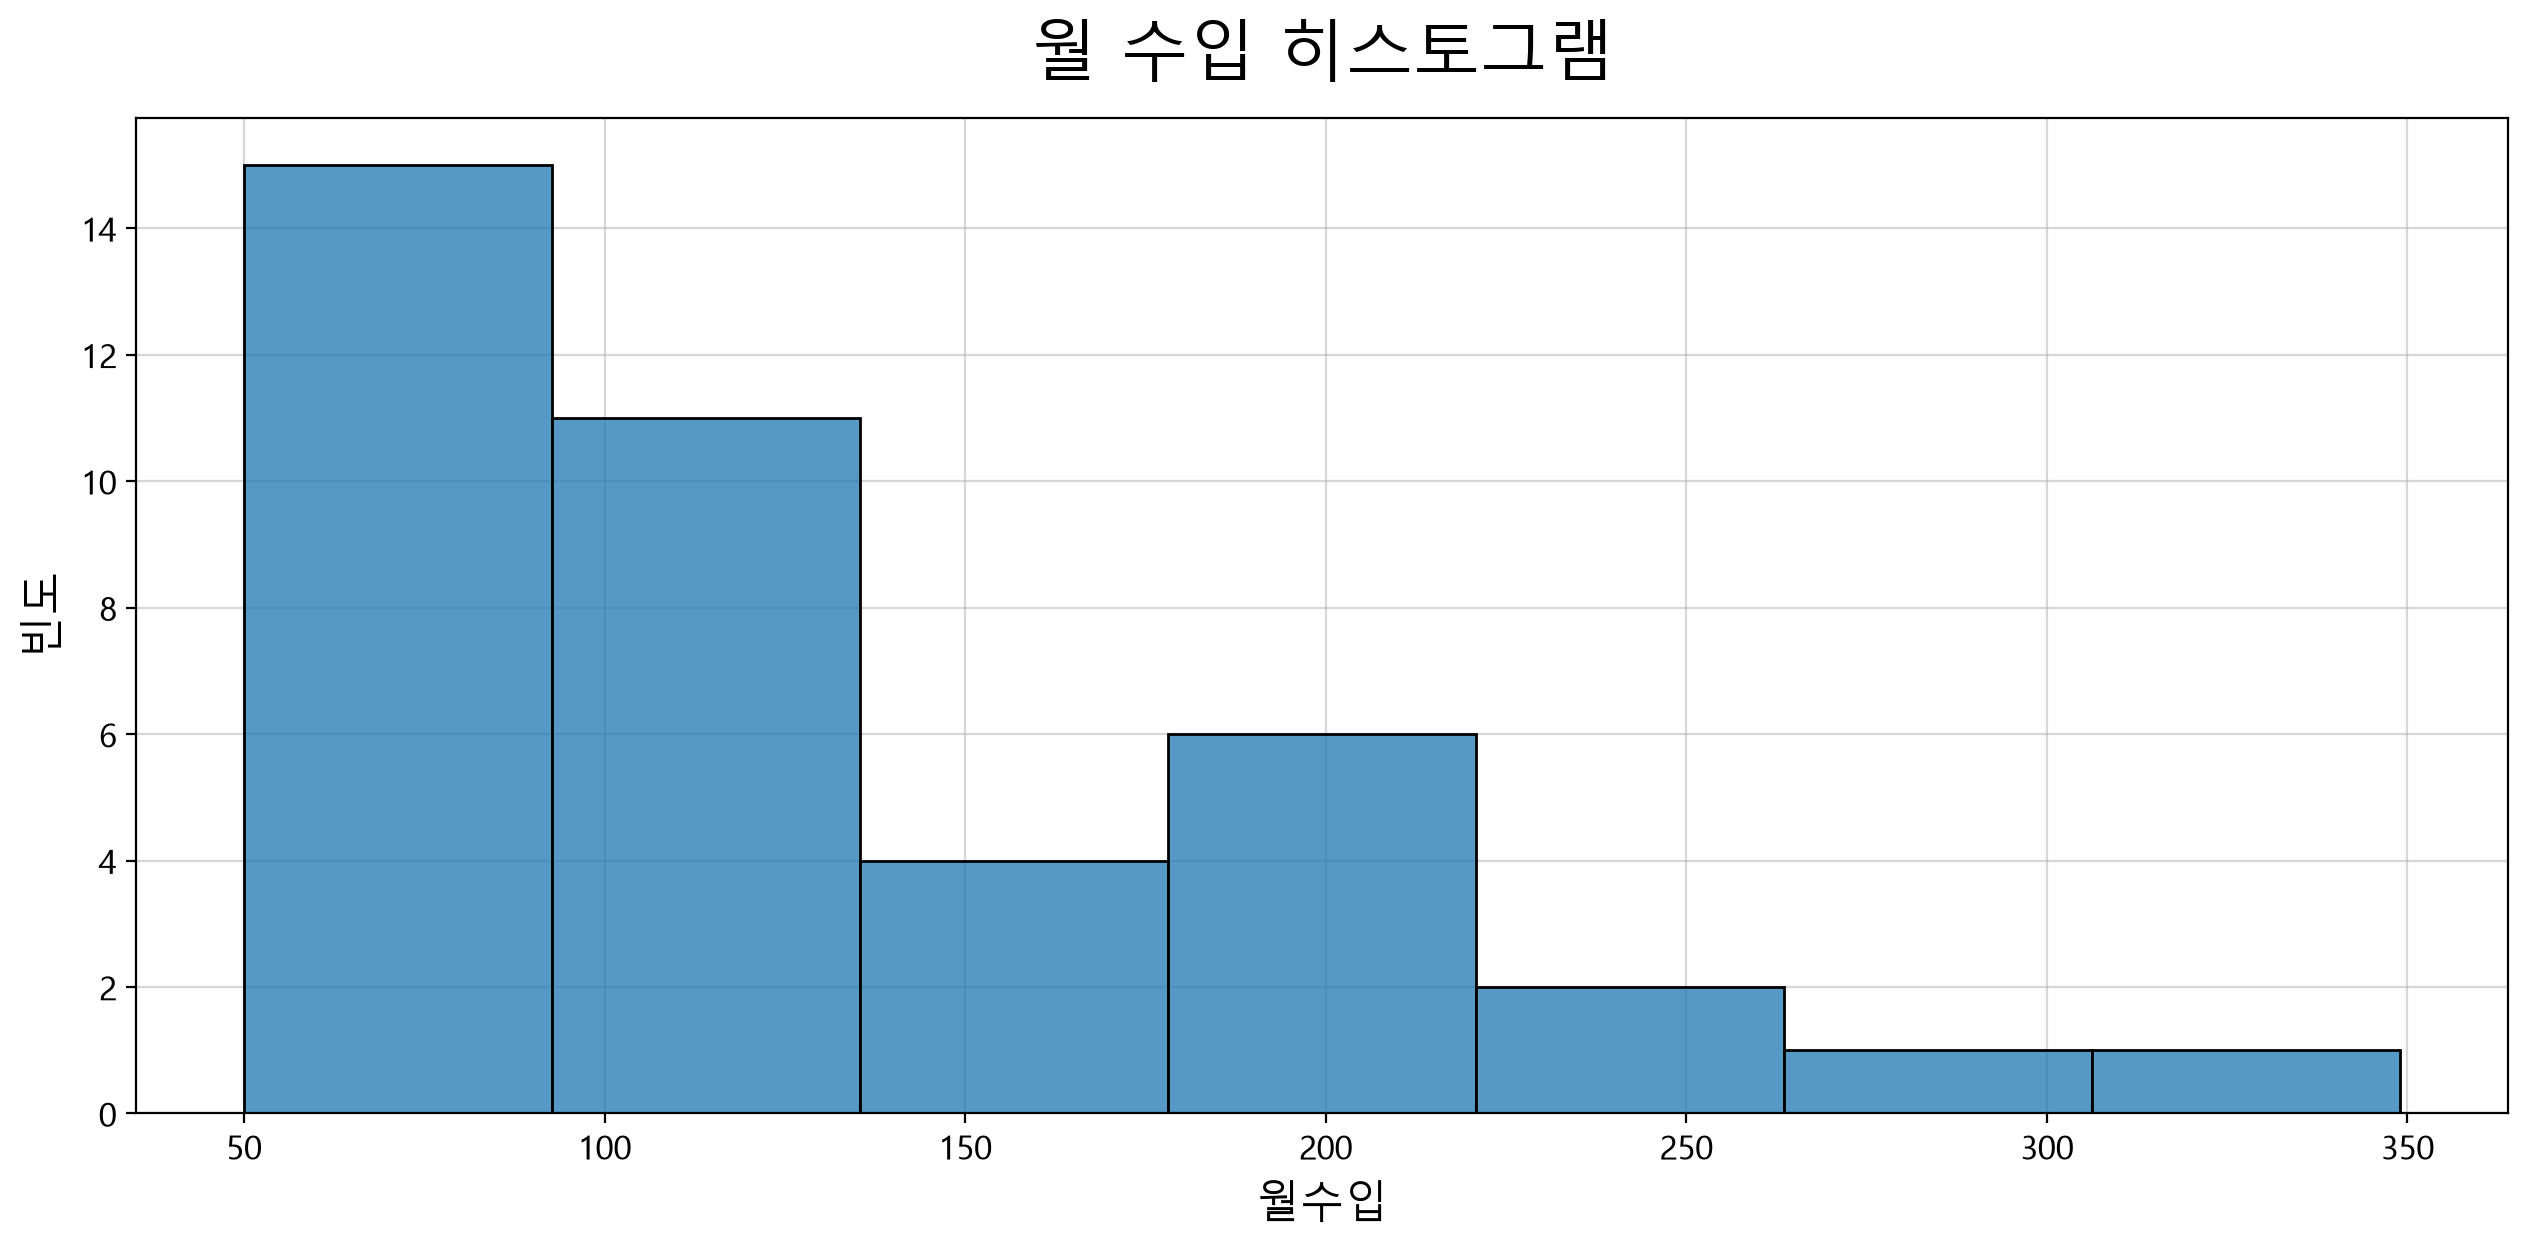

In [3]:
fig, ax = my_plot.init(title='월 수입 히스토그램', 
                       xlabel='월수입', ylabel='빈도')

# 패턴1 - 자동인식 패턴 
# sb.histoplot(data=origin['월수입'])

# 패턴2 - 개별 데이터 직접 지정 패턴 
# sb.histplot(x=origin['월수입'])

# 패턴3 - DataFrame + 컬럼명 패턴 
sb.histplot(data=origin, x='월수입')

my_plot.show()

## #03. 히스토그램의 구간 설정 

### 2. Numpy를 통해 정확한 구간경계 얻기 

In [4]:
hist, bins = np.histogram(origin['월수입'], bins=5) 

# 소수점 1째자리까지 남기고 반올림 
bisn = np.round(bins, 1)
print("값:", hist)
print("구간:", bins)

값: [20  9  7  2  2]
구간: [ 50.  109.8 169.6 229.4 289.2 349. ]


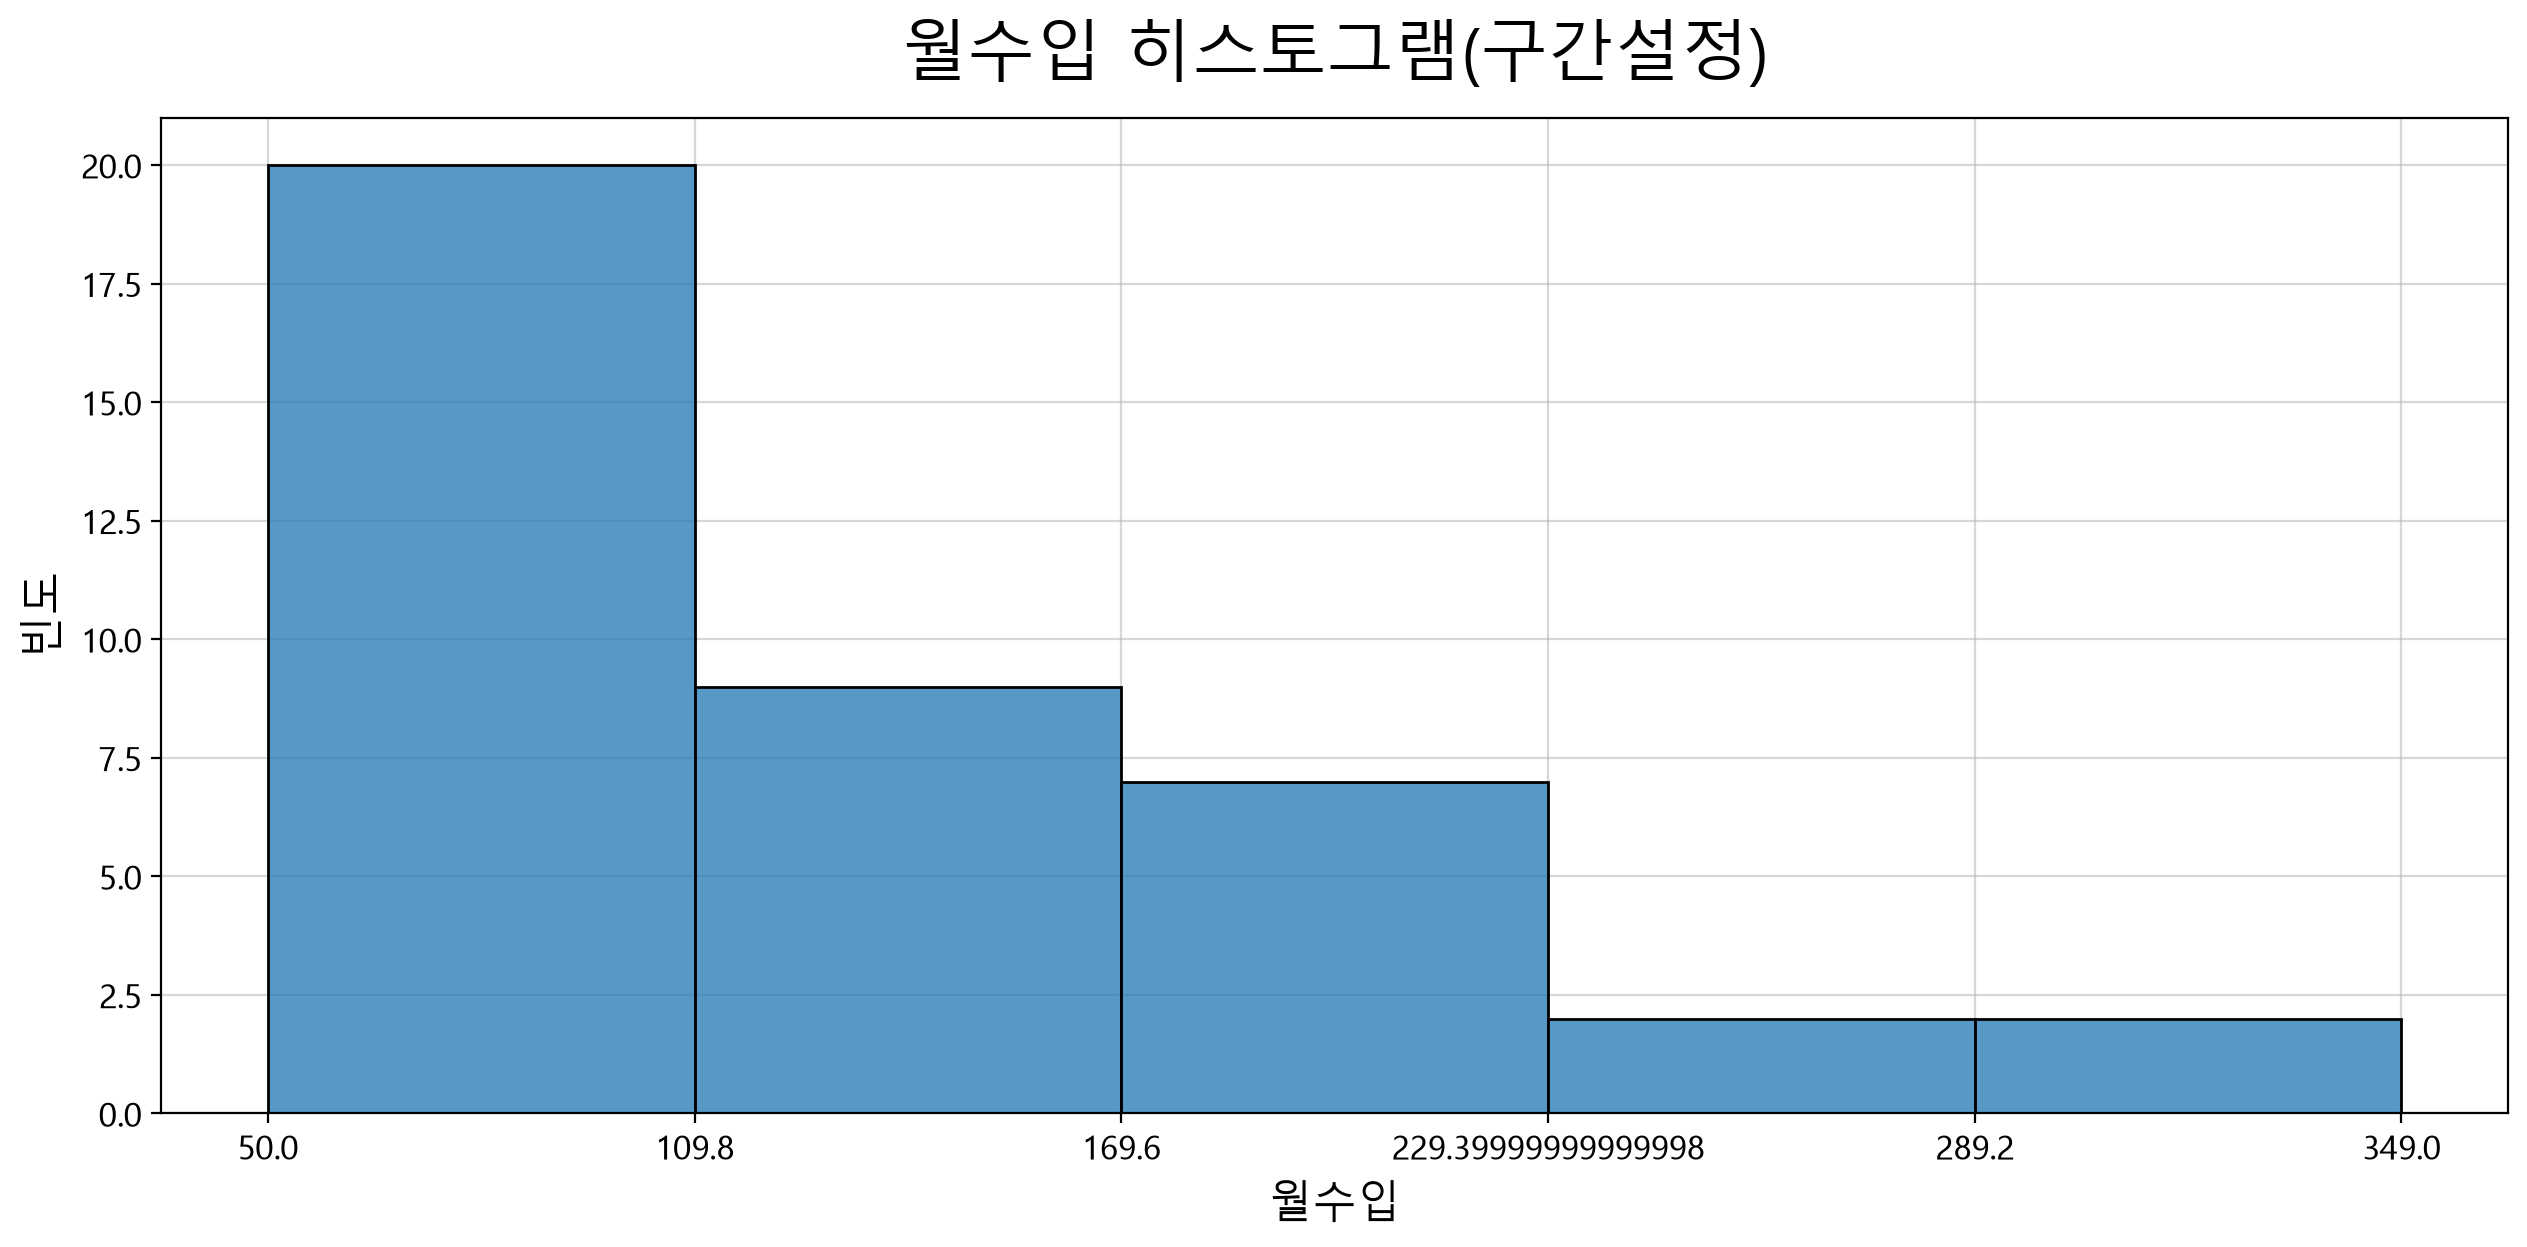

In [5]:
fig, ax = my_plot.init(title='월수입 히스토그램(구간설정)', 
                       xlabel='월수입', ylabel='빈도')

# 구간을 설정한 히스토그램 
# -> bins는 이전 코드 블록에서 생성한 정보 
sb.histplot(data=origin, x='월수입', bins=bins)

# x축 좌표에 구간값 표시하기 
ax.set_xticks(bins, bins)

my_plot.show()

## #04. 히스토그램의 옵션 설정 

### 1. 커널밀도와 함께 표시하기 
- kde = True 파라미터를 추가한다. 

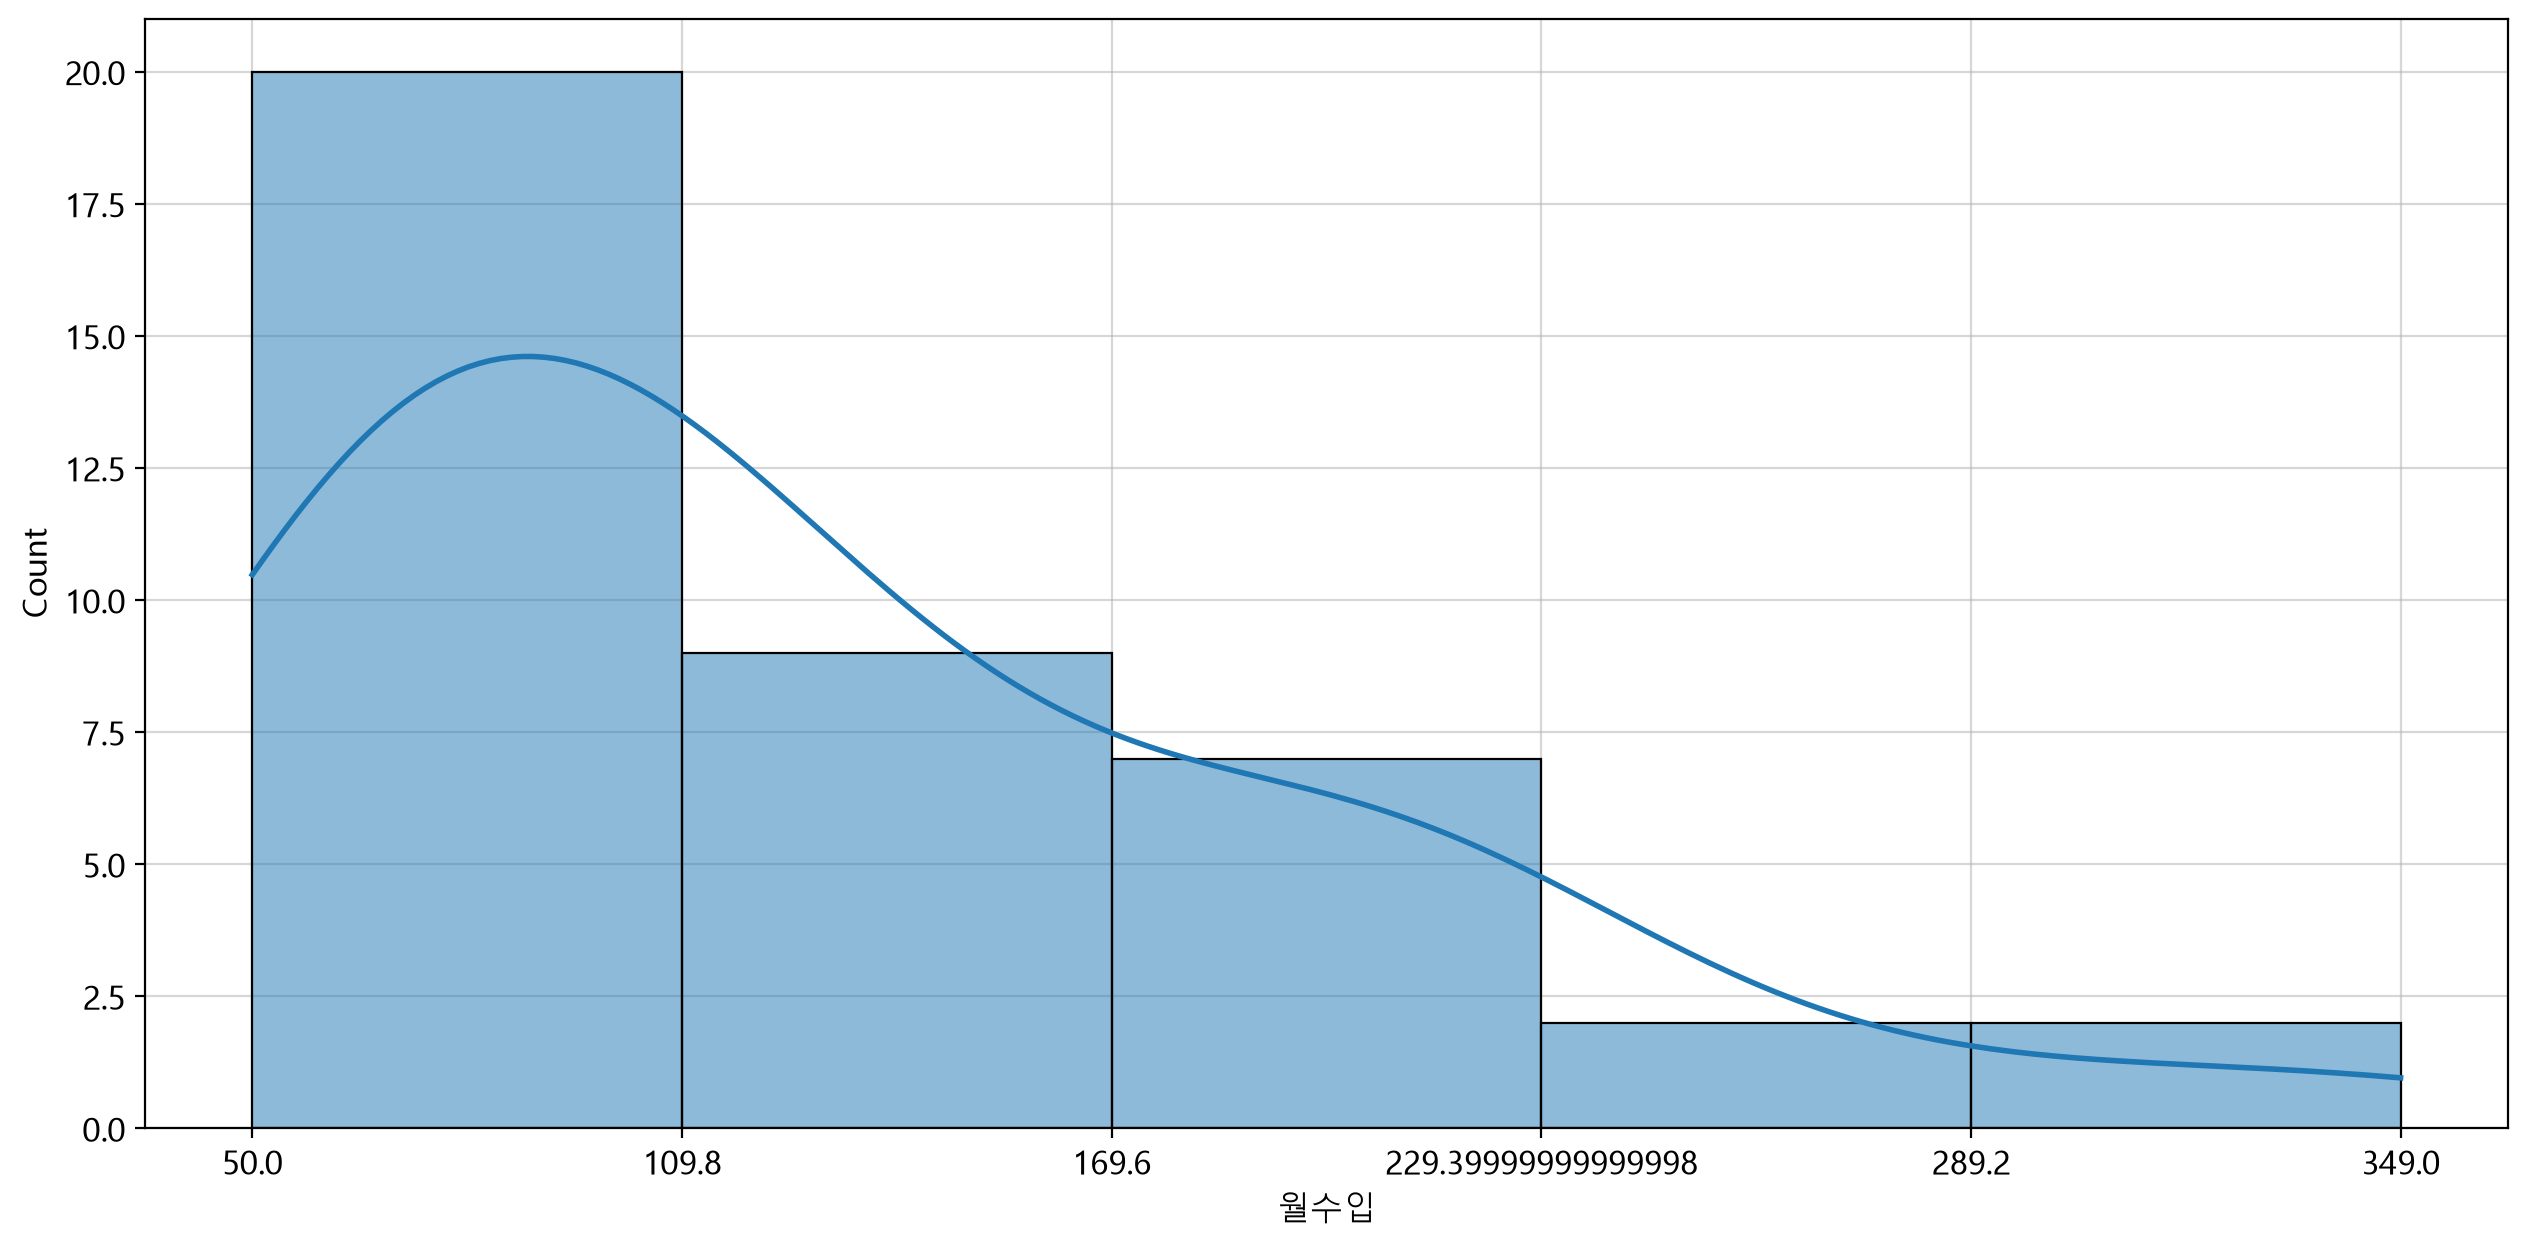

In [6]:
# 그래프 초기화 
fig, ax = my_plot.init()

# 구간을 설정한 히스토그램 -> bins 는 이전 코드 블록에서 생성한 정보 
sb.histplot(data=origin, x='월수입', bins=bins, kde=True, linewidth=0.8)

# x축 좌표에 구간값 표시하기 
ax.set_xticks(bins, bins)

# 출력
my_plot.show()

### 2. 범주 구분, 선 색상/ 굵기 설정하기 
- 성별에 따른 월 수입 히스토그램 

<Axes: title={'center': '성별에 따른 월수입 히스토그램'}, xlabel='월수입', ylabel='빈도'>

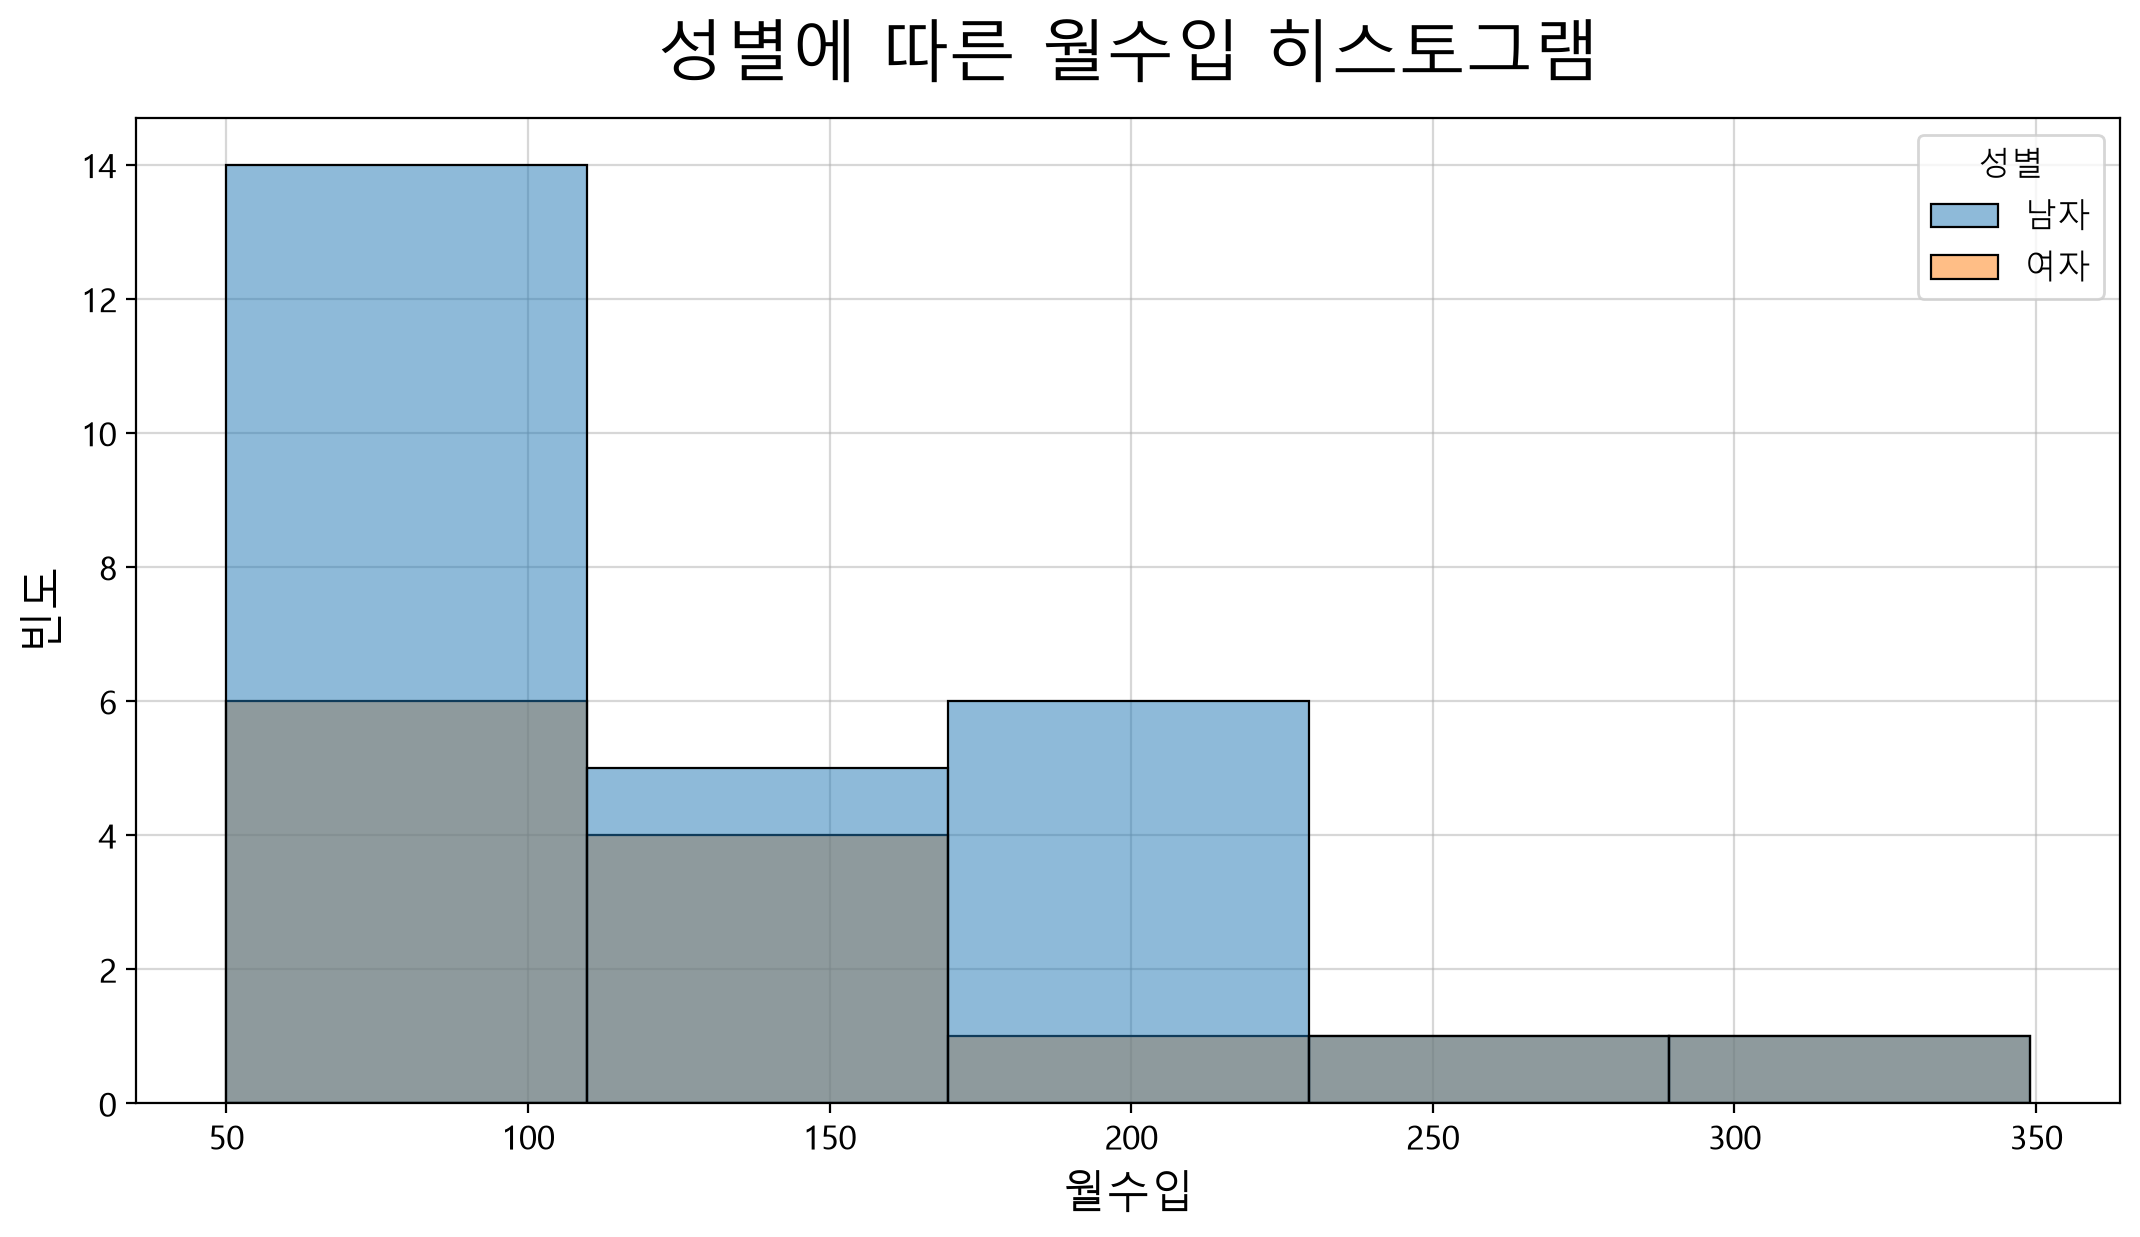

In [7]:
fig, ax = my_plot.init(title='성별에 따른 월수입 히스토그램', 
                       xlabel='월수입', ylabel='빈도')

sb.histplot(data=origin, x='월수입', hue='성별', bins=bins, 
            edgecolor="#000000", linewidth=0.8)

## #05. 모듈화 기능 확인 

### 1. 히스토그램 모듈 사용하기 

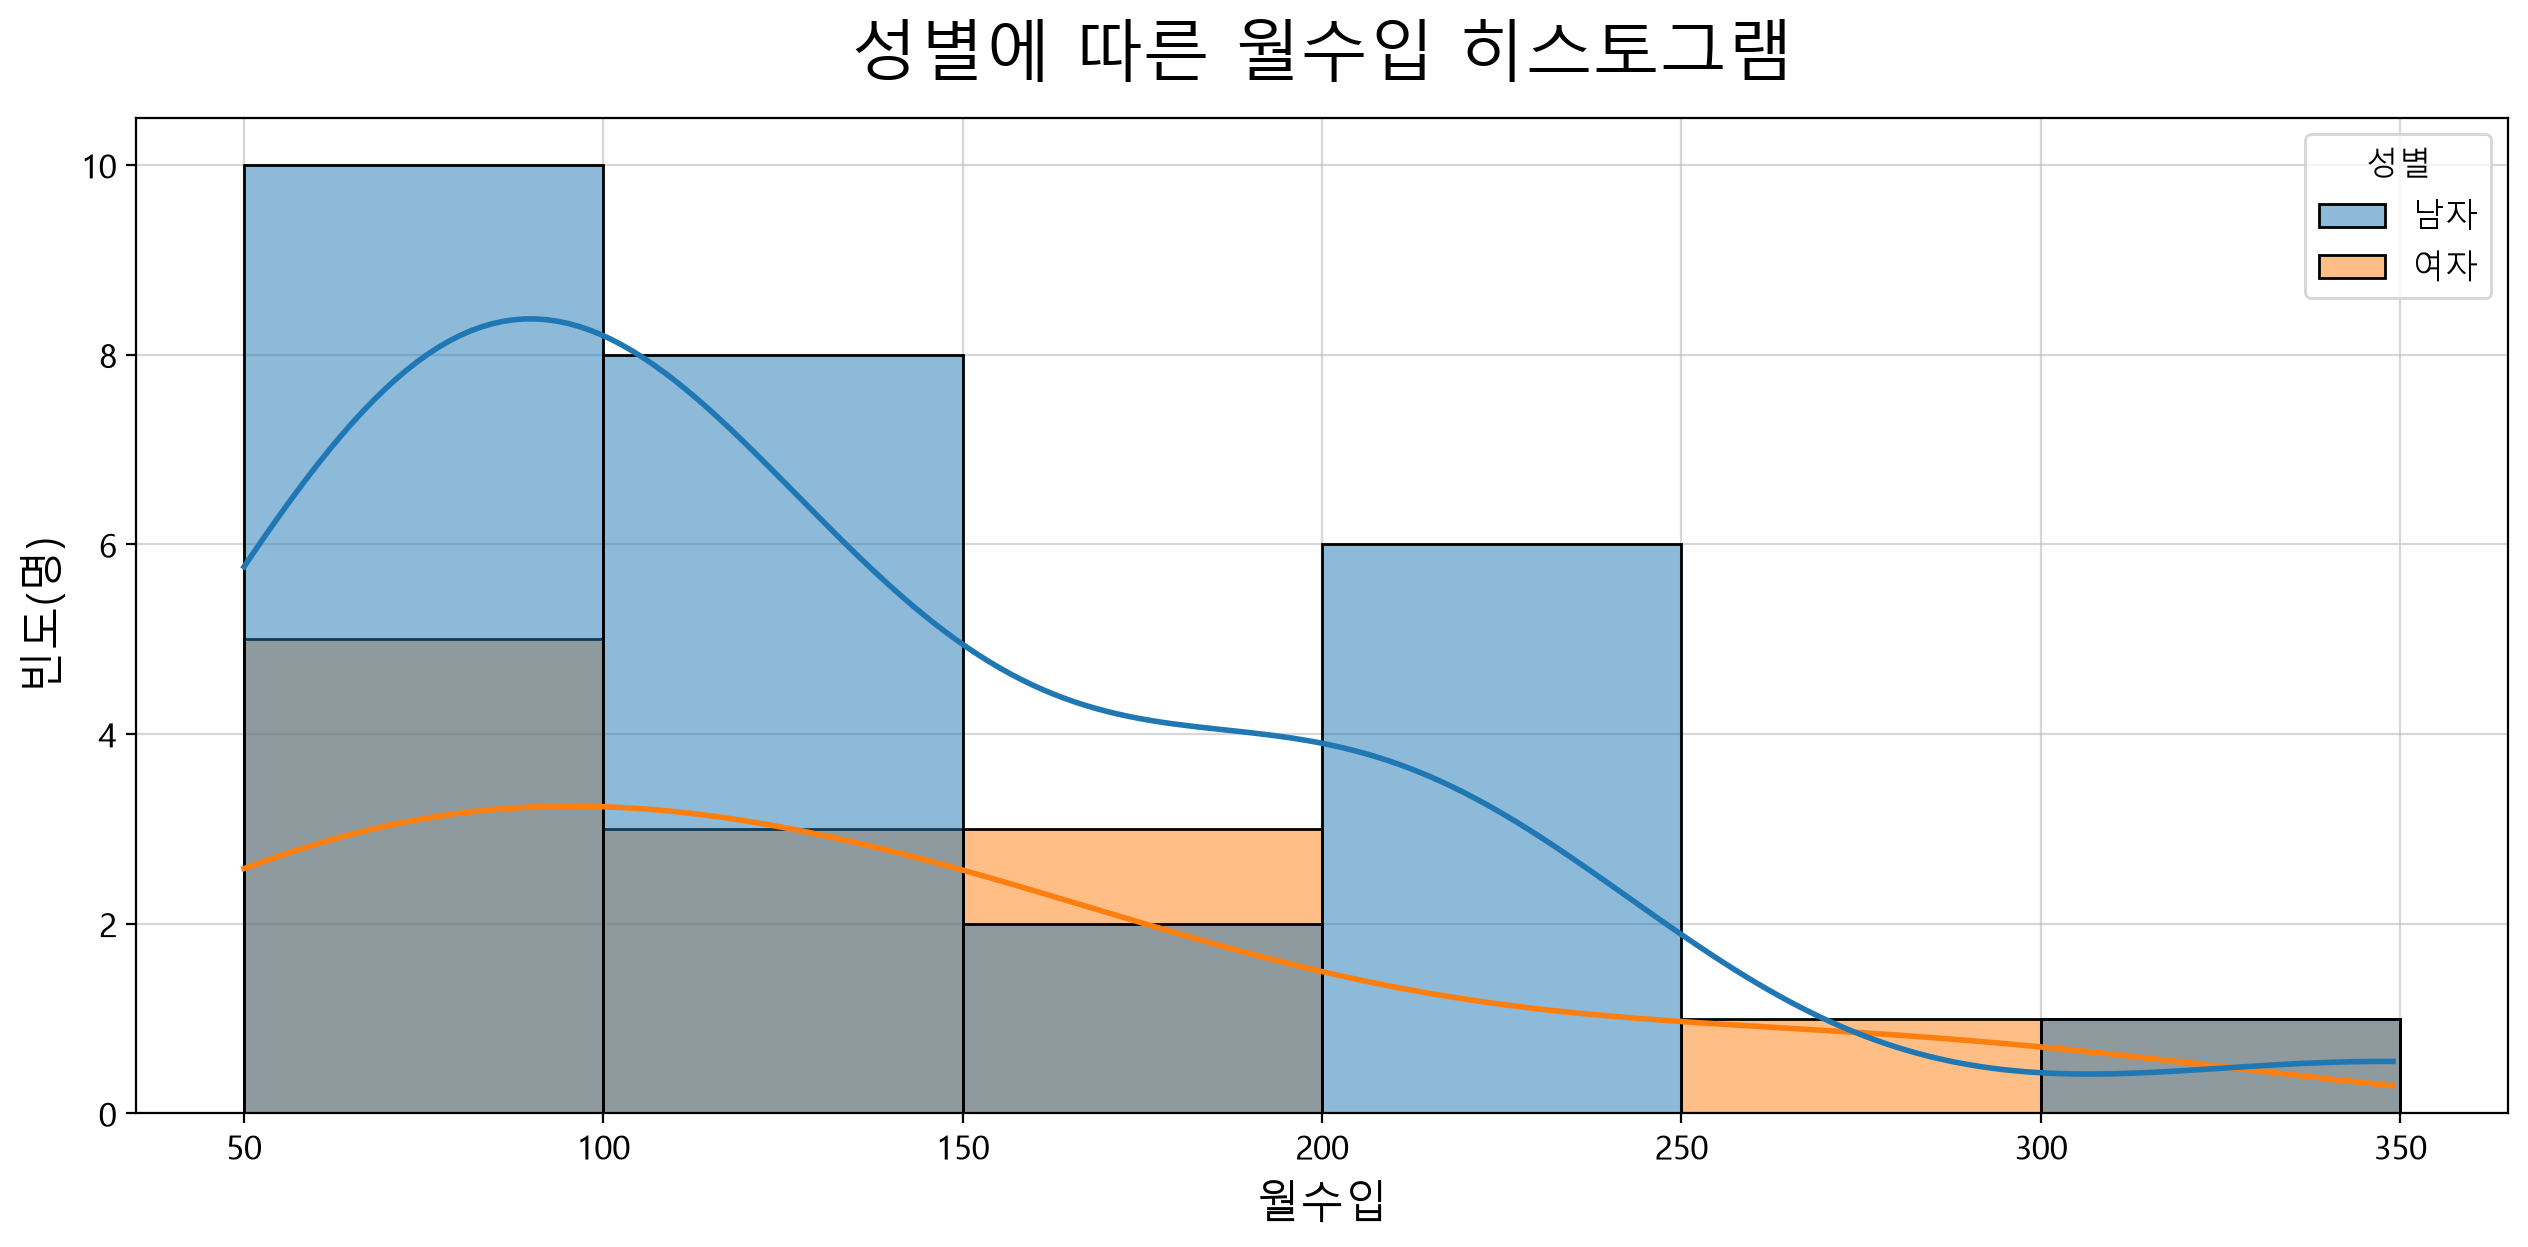

In [8]:
my_plot.histplot(data=origin, x='월수입', hue='성별', 
                  bins=[50, 100, 150, 200, 250, 300, 350], kde=True,
                  title='성별에 따른 월수입 히스토그램', 
                  xlabel='월수입', ylabel='빈도(명)')

## #01. 연습문제 

In [9]:
from jussam import load_data
from helpers import * 
import seaborn as sb
import numpy as np

In [10]:
origin = load_data("stat_comp_grade")
origin.head()

📚 통계학 전공(STAT) 학생과 전산학 전공(COMP) 학생의 통계학 과목에 대한 중간고사 성적과 기말시험 성적 (출처: 방송통신대학교 통계학개론 수업내용에서 발췌)


,전공,중간고사,기말고사
0,STAT,34,86
1,STAT,50,77
2,STAT,75,74
3,COMP,76,96
4,COMP,61,78


전공별로 중간고사와 기말고사 성적에 대한 히스토그램 

COMP 
STAT
각각 봐야 함. 

In [11]:
df1 = origin[origin['전공'] == 'STAT']
df1

,전공,중간고사,기말고사
0,STAT,34,86
1,STAT,50,77
2,STAT,75,74
7,STAT,47,57
8,STAT,94,82
10,STAT,38,53
11,STAT,65,70
12,STAT,47,60
13,STAT,88,95
16,STAT,92,95


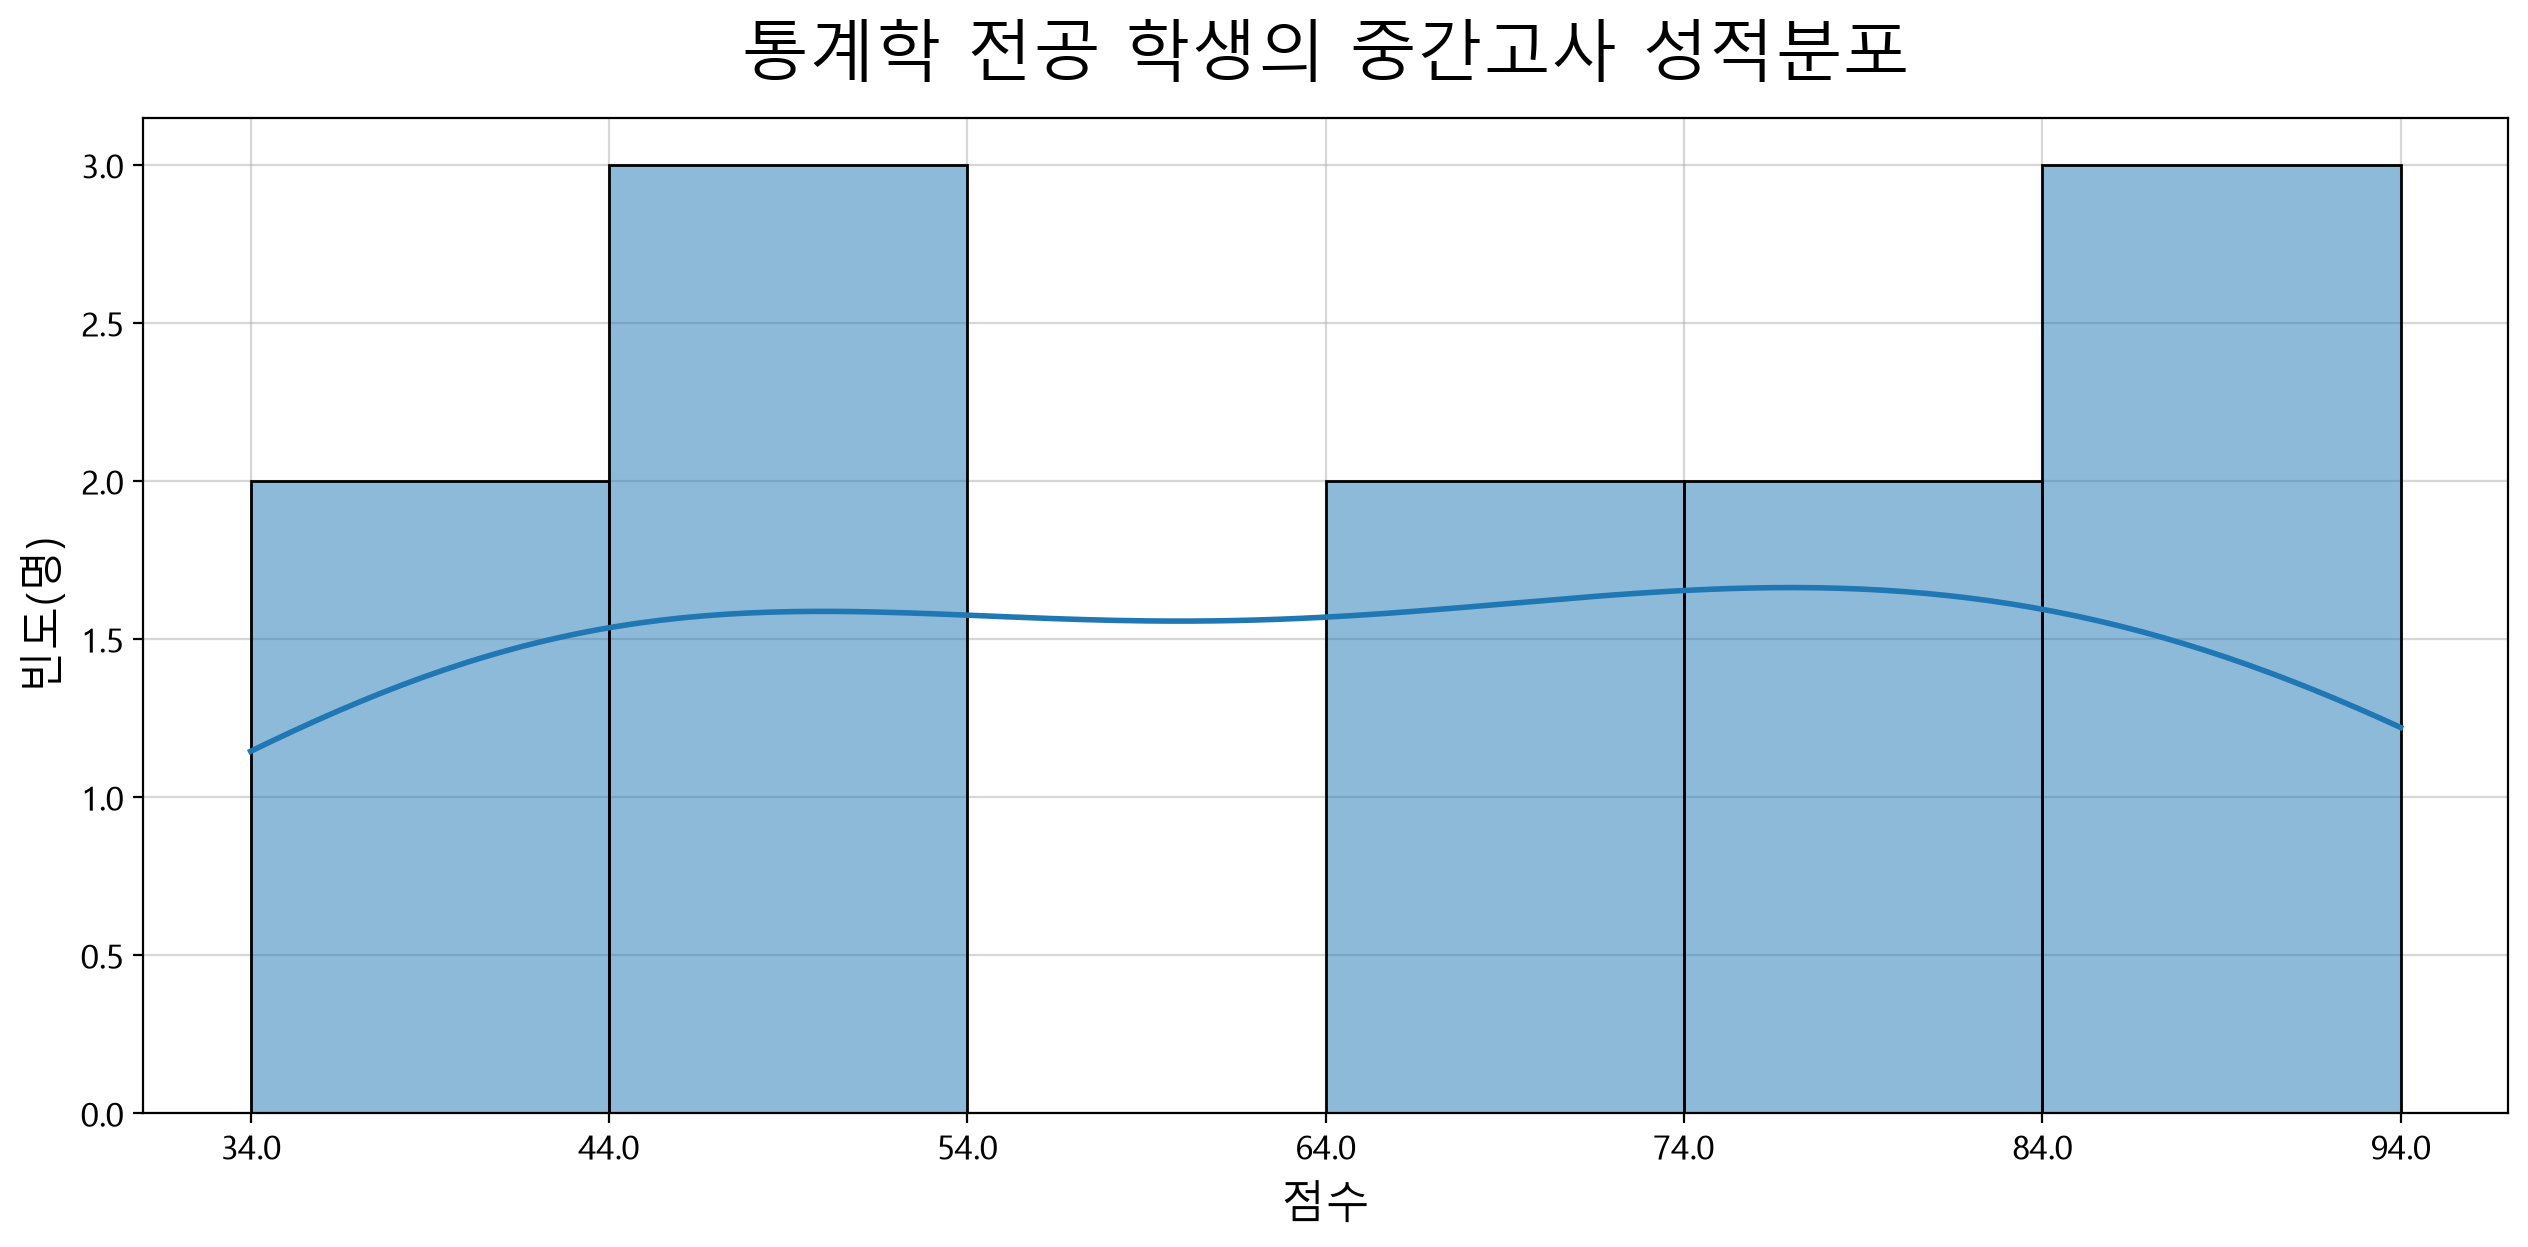

In [12]:
my_plot.histplot(data=df1, 
                 x='중간고사', bins=6, kde=True, 
                 title='통계학 전공 학생의 중간고사 성적분포', 
                 xlabel='점수', ylabel='빈도(명)'
                 )

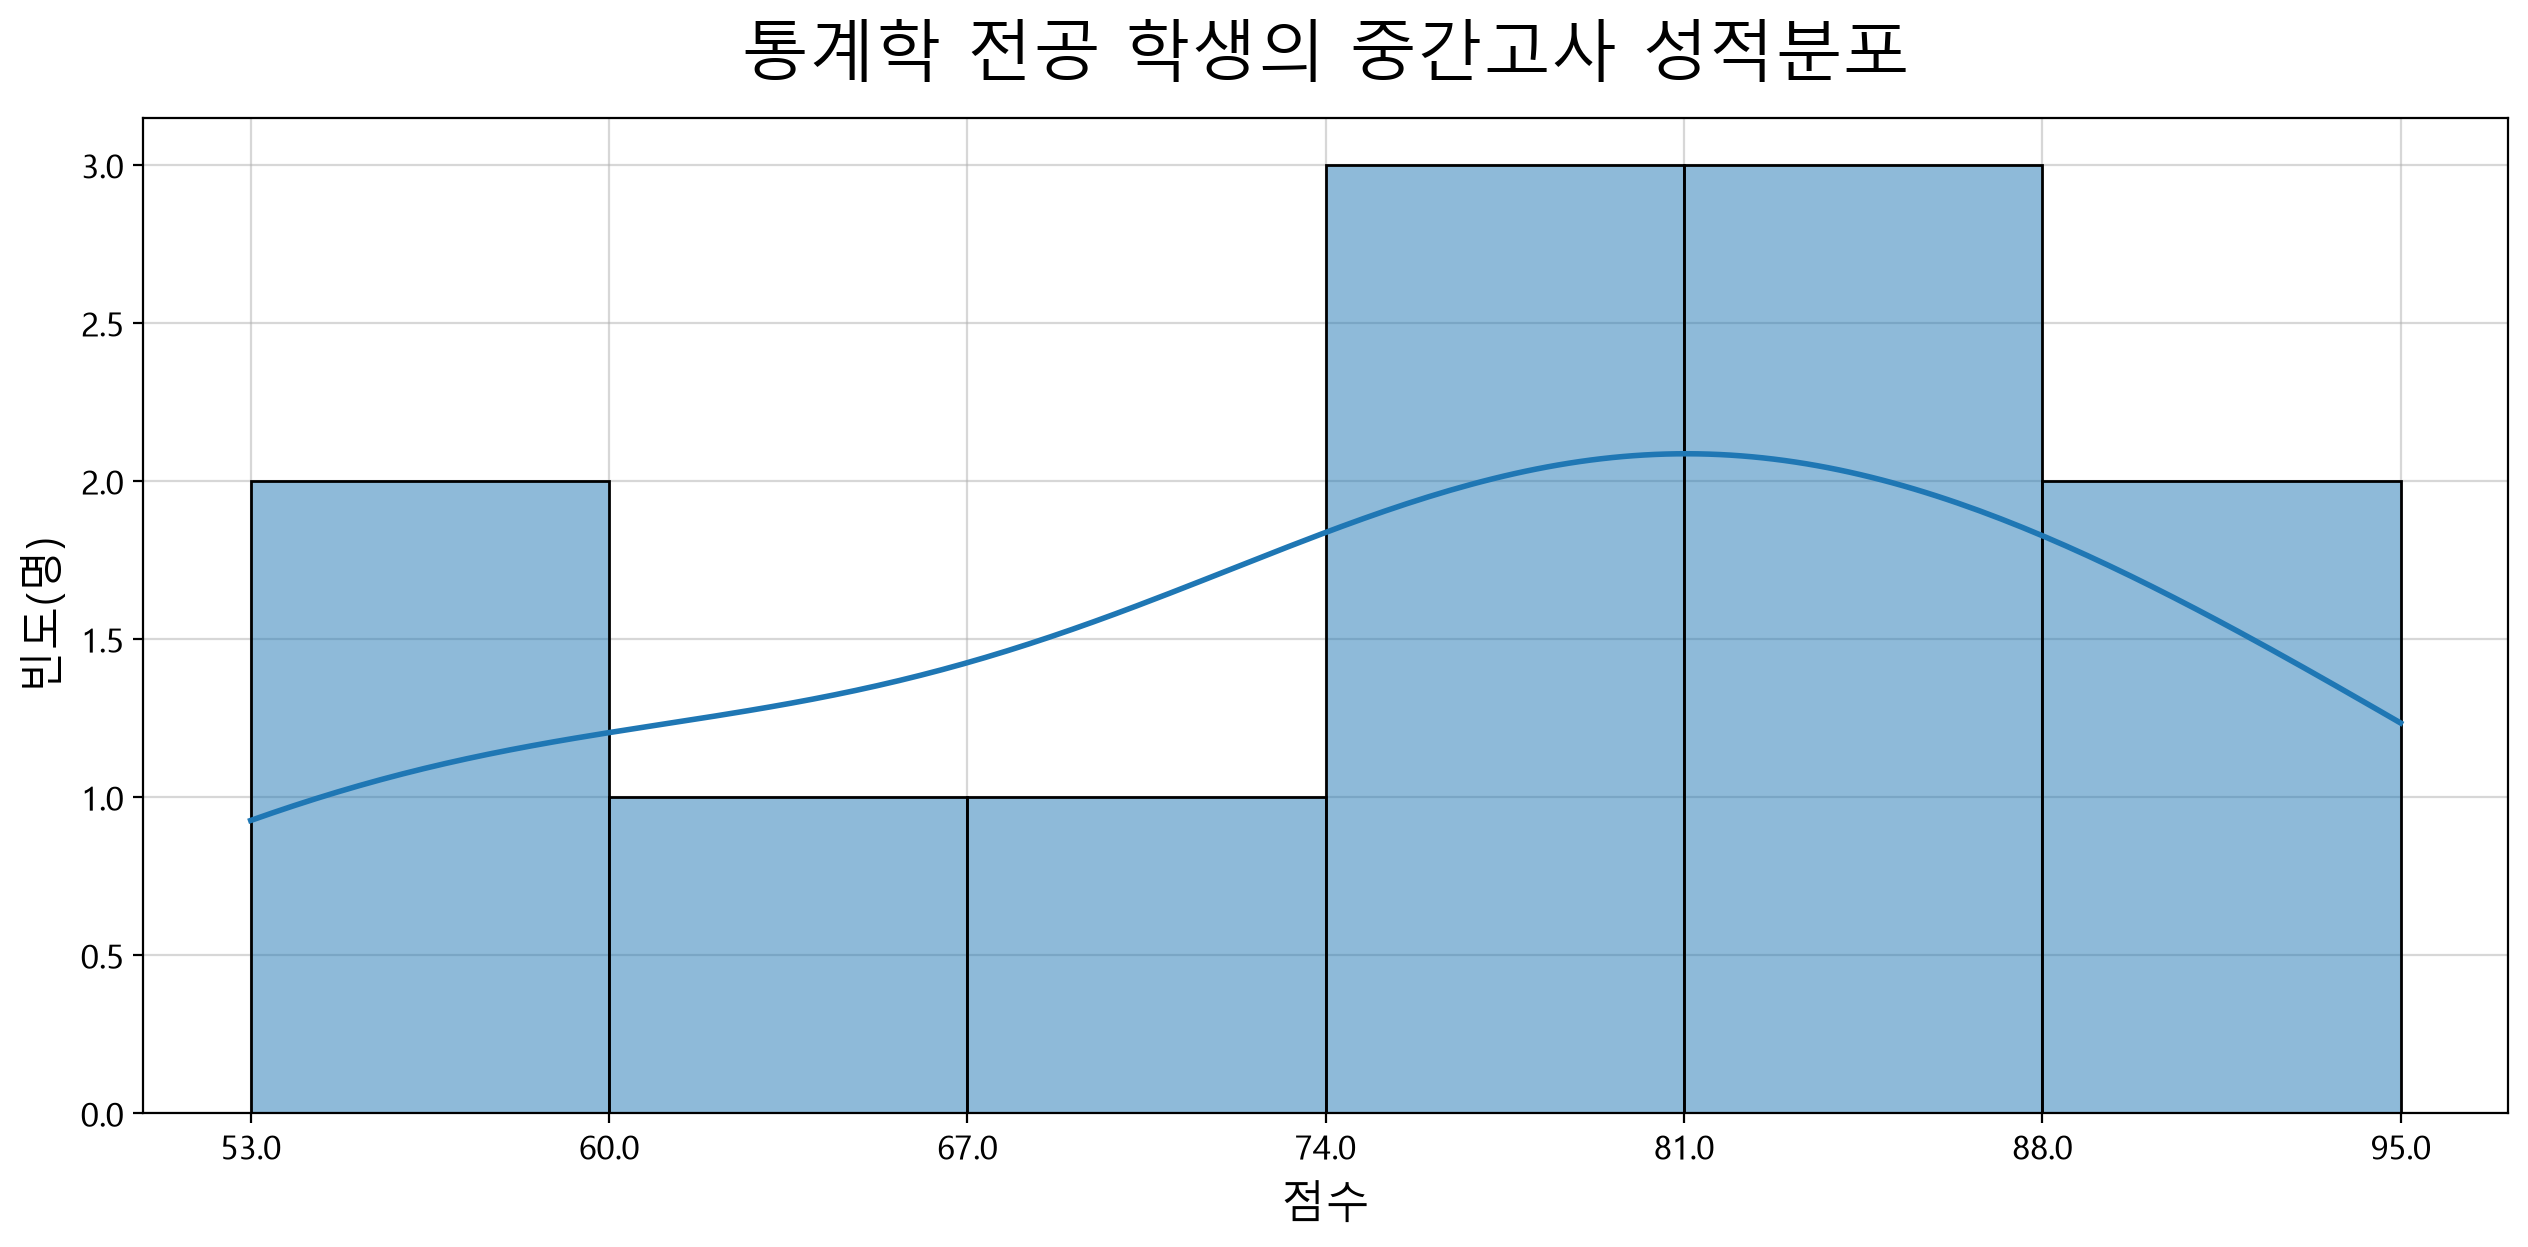

In [13]:
my_plot.histplot(data=df1, 
                 x='기말고사', bins=6, kde=True,
                title='통계학 전공 학생의 중간고사 성적분포', 
                 xlabel='점수', ylabel='빈도(명)')

In [14]:
df2 = origin[origin['전공'] == 'COMP']
df2

,전공,중간고사,기말고사
3,COMP,76,96
4,COMP,61,78
5,COMP,65,40
6,COMP,31,68
9,COMP,49,57
14,COMP,80,85
15,COMP,87,90
19,COMP,76,85


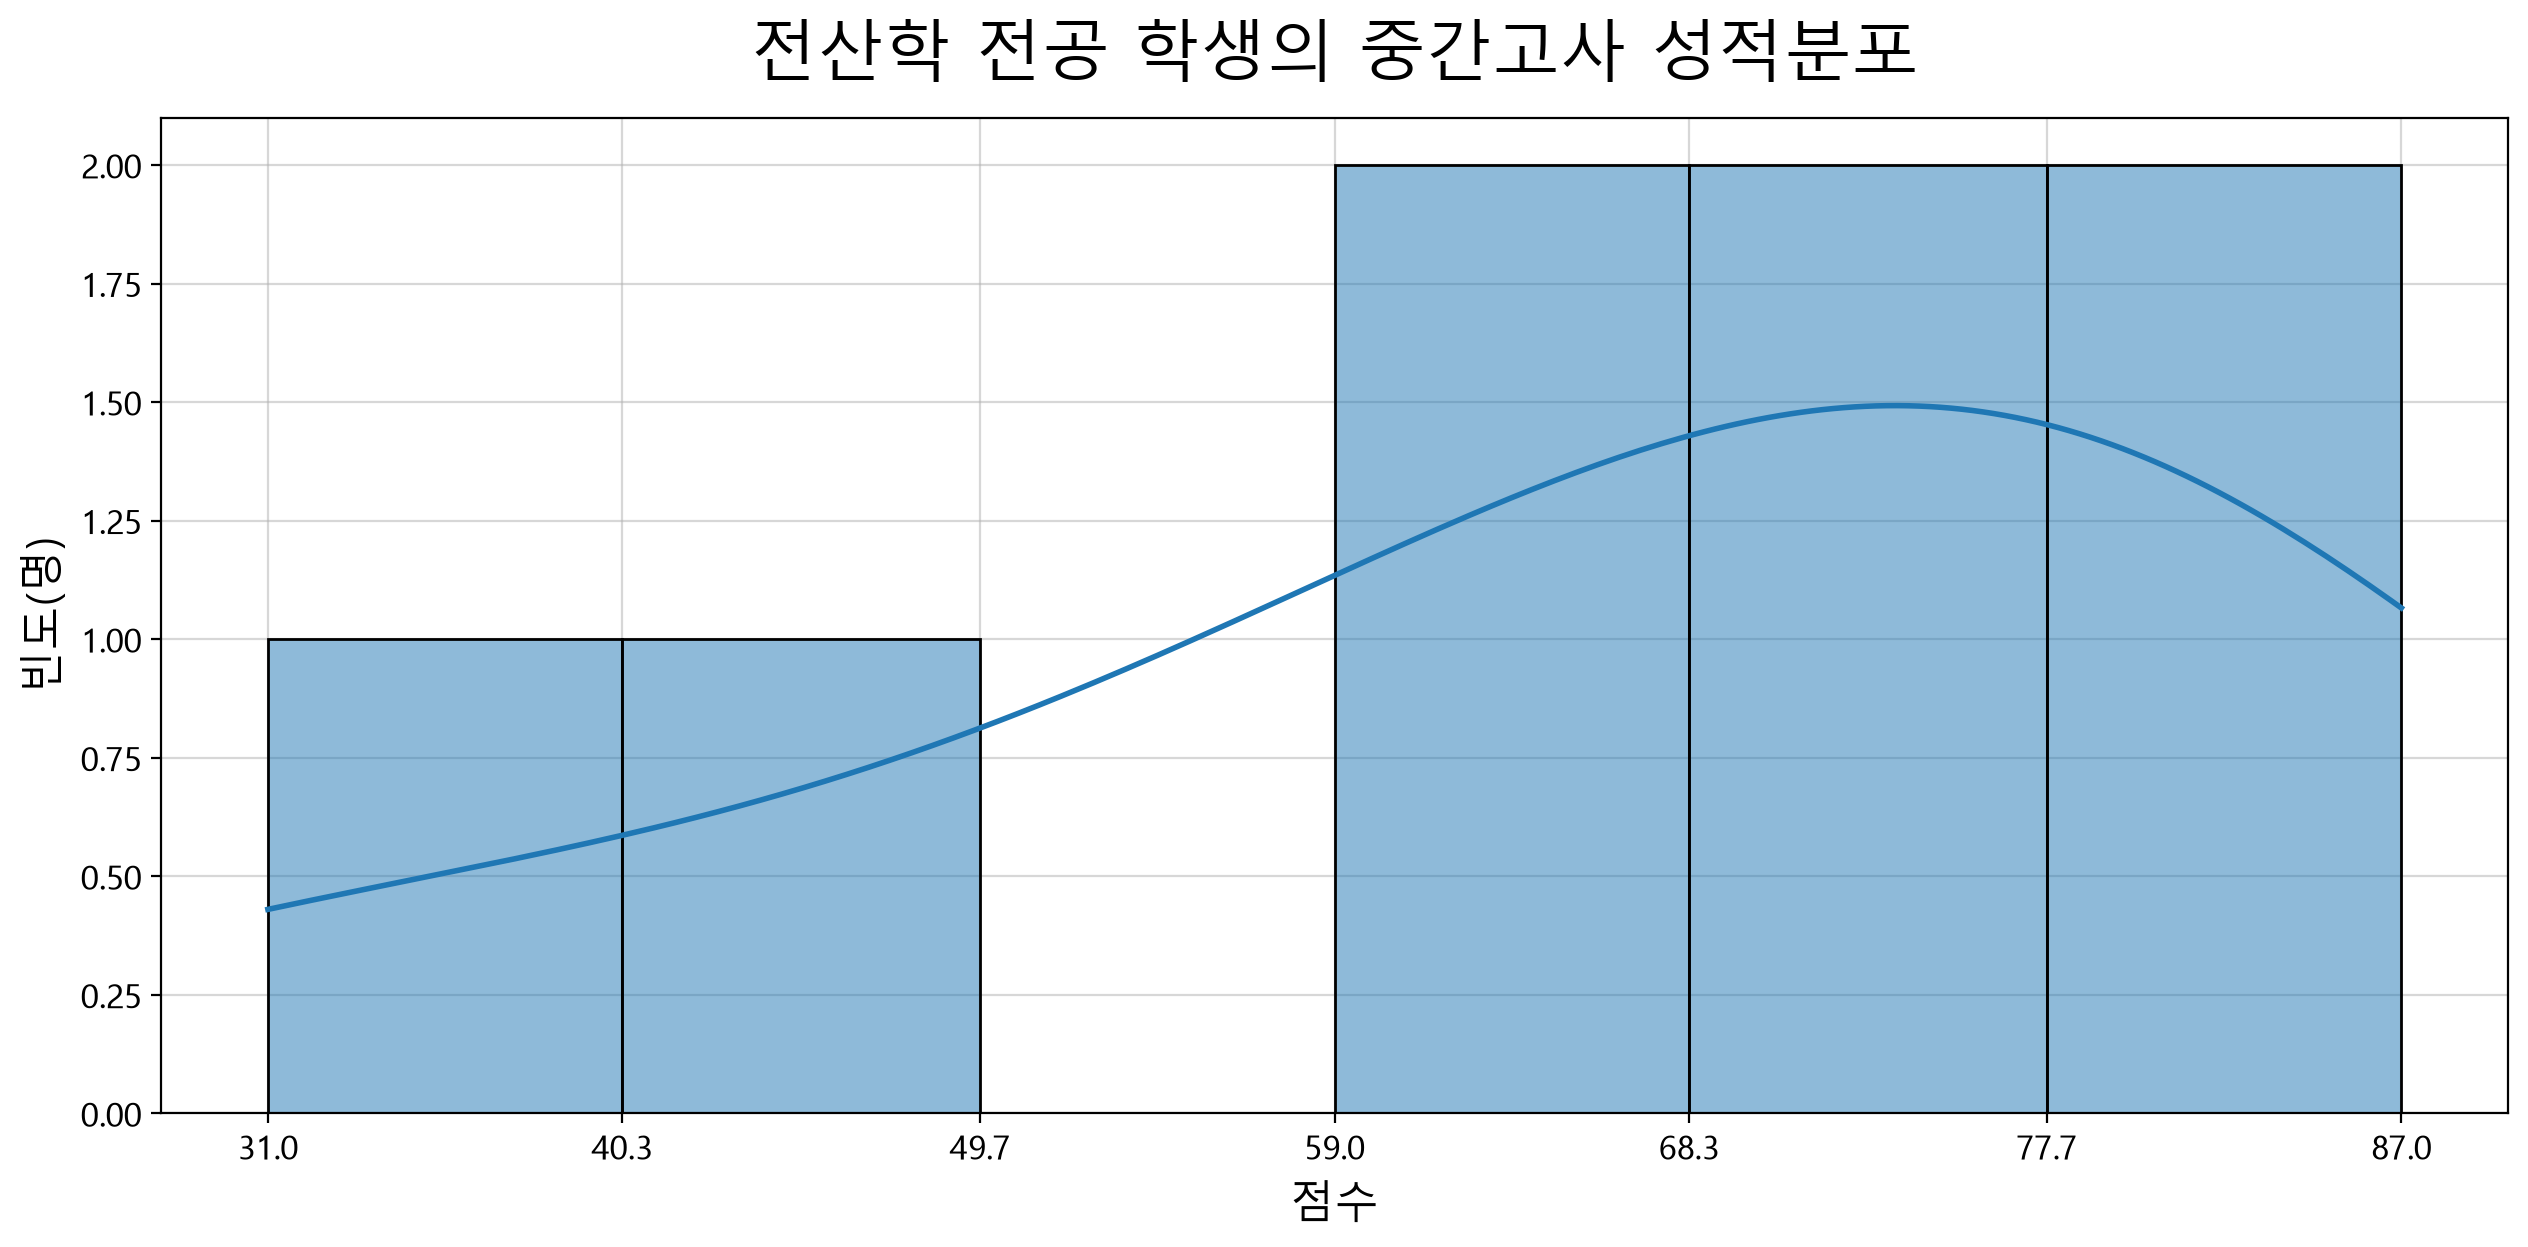

In [15]:
my_plot.histplot(data=df2, 
                 x='중간고사', bins=6, kde=True,
                title='전산학 전공 학생의 중간고사 성적분포', 
                 xlabel='점수', ylabel='빈도(명)'
                 )

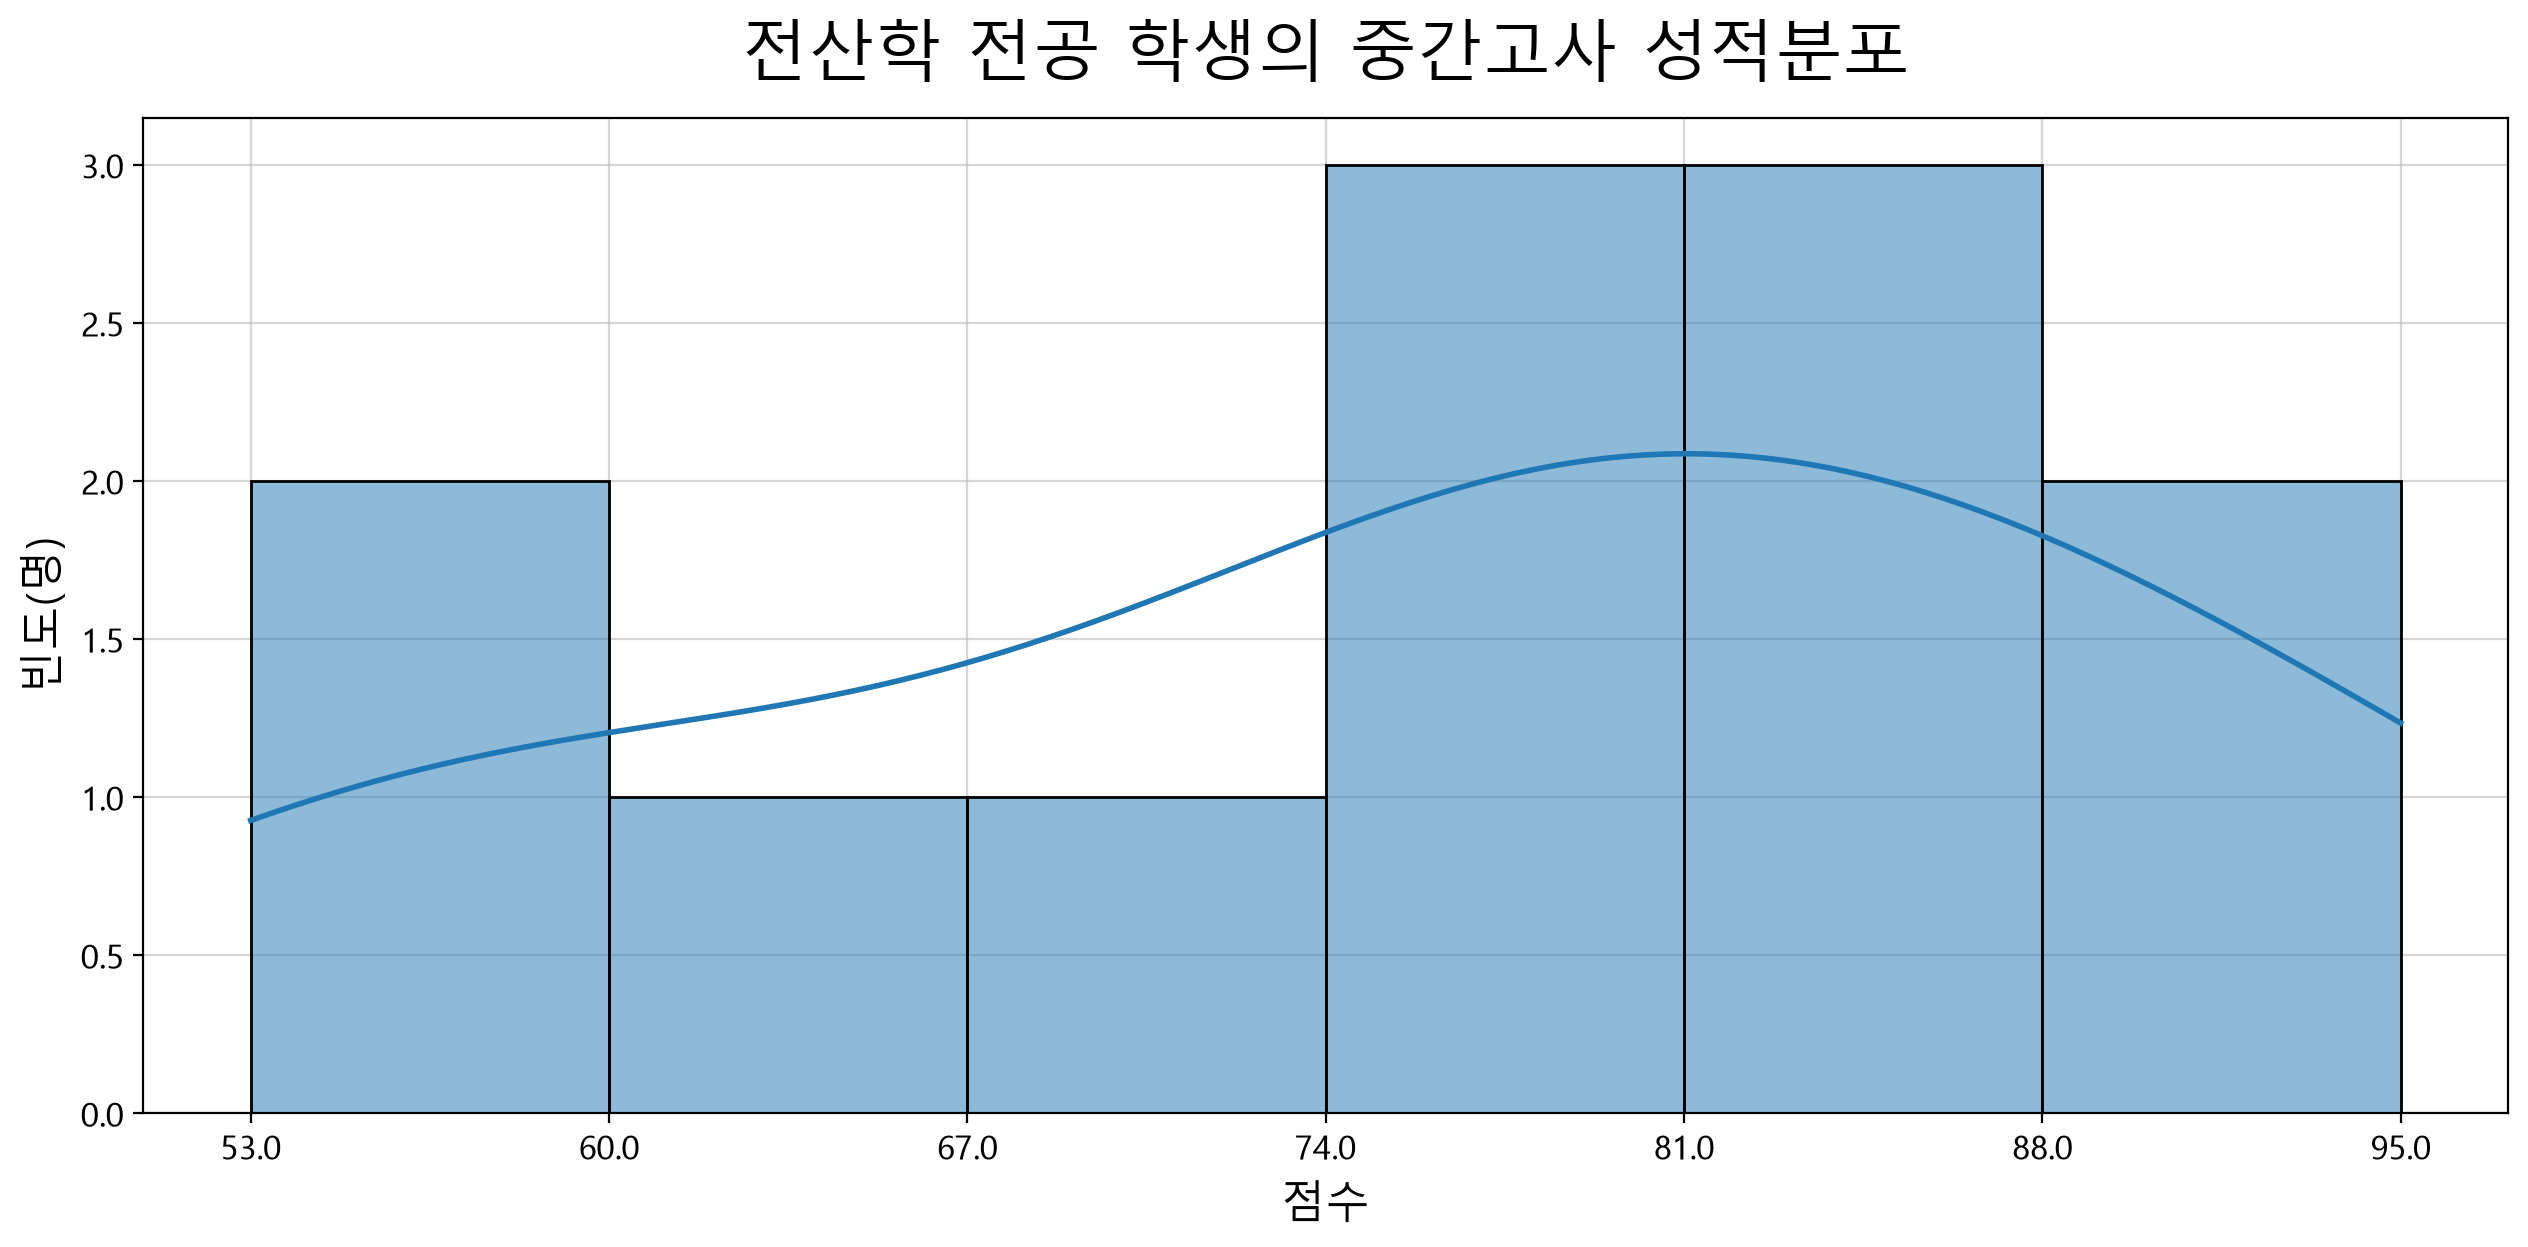

In [16]:
my_plot.histplot(data=df1, 
                 x='기말고사', bins=6, kde=True,
                 title='전산학 전공 학생의 중간고사 성적분포', 
                 xlabel='점수', ylabel='빈도(명)'
                 )

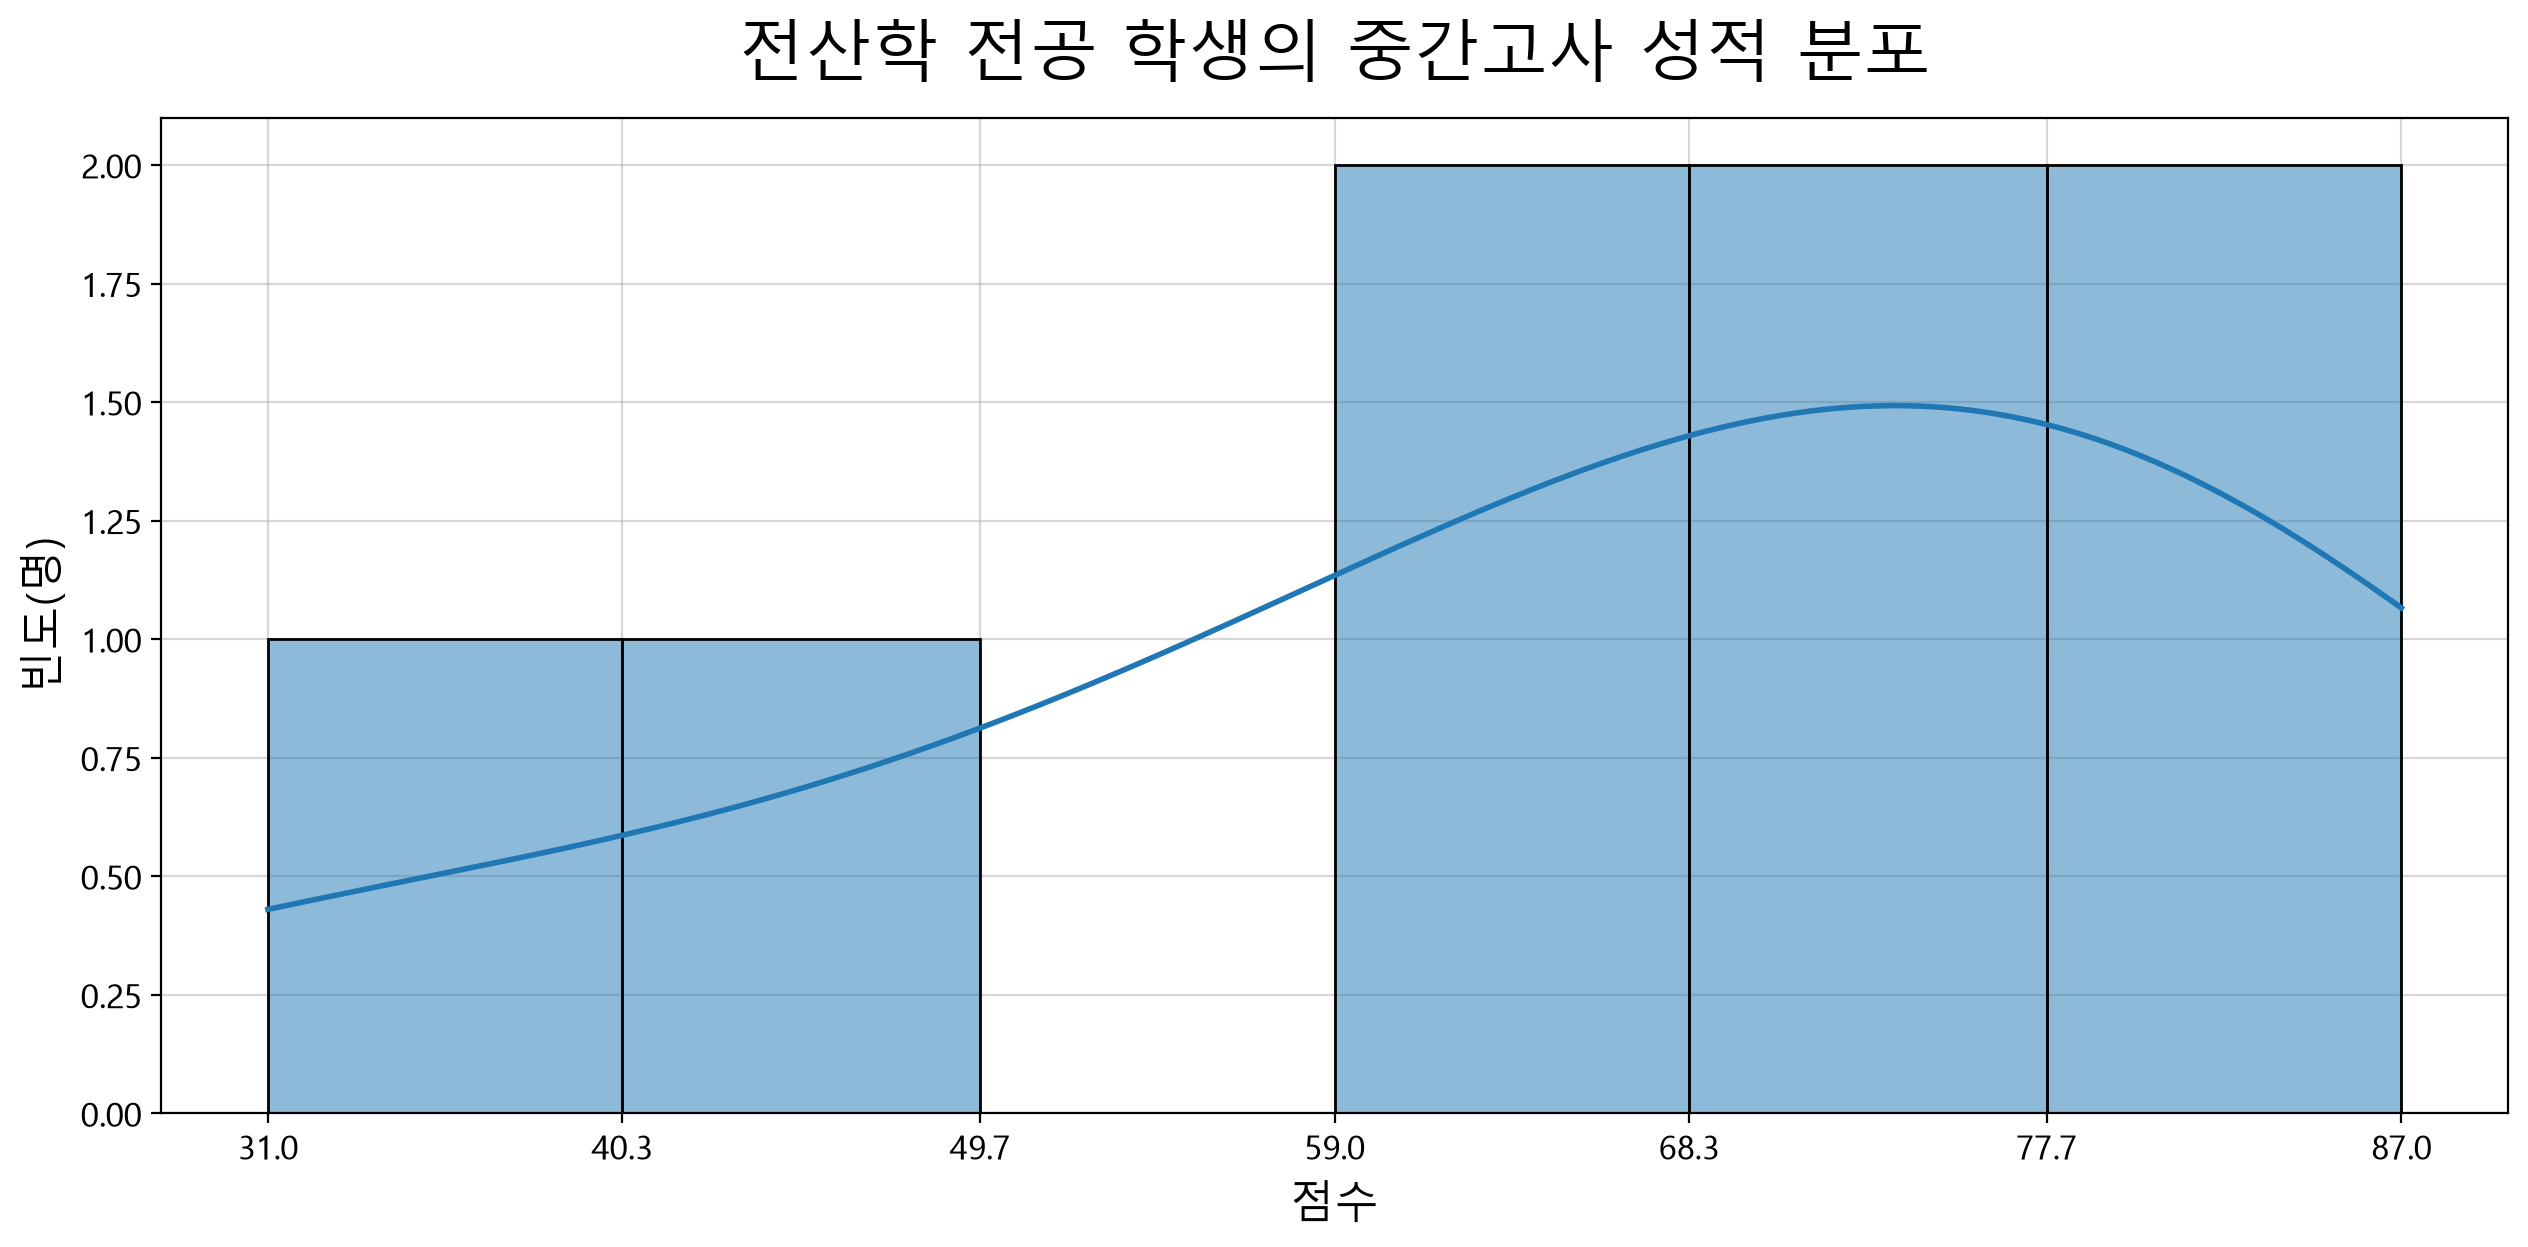

In [17]:
my_plot.histplot(data=origin[origin['전공'] == 'COMP'], 
                 x='중간고사', bins=6, kde=True,
                 title='전산학 전공 학생의 중간고사 성적 분포', 
                 xlabel='점수', ylabel='빈도(명)')

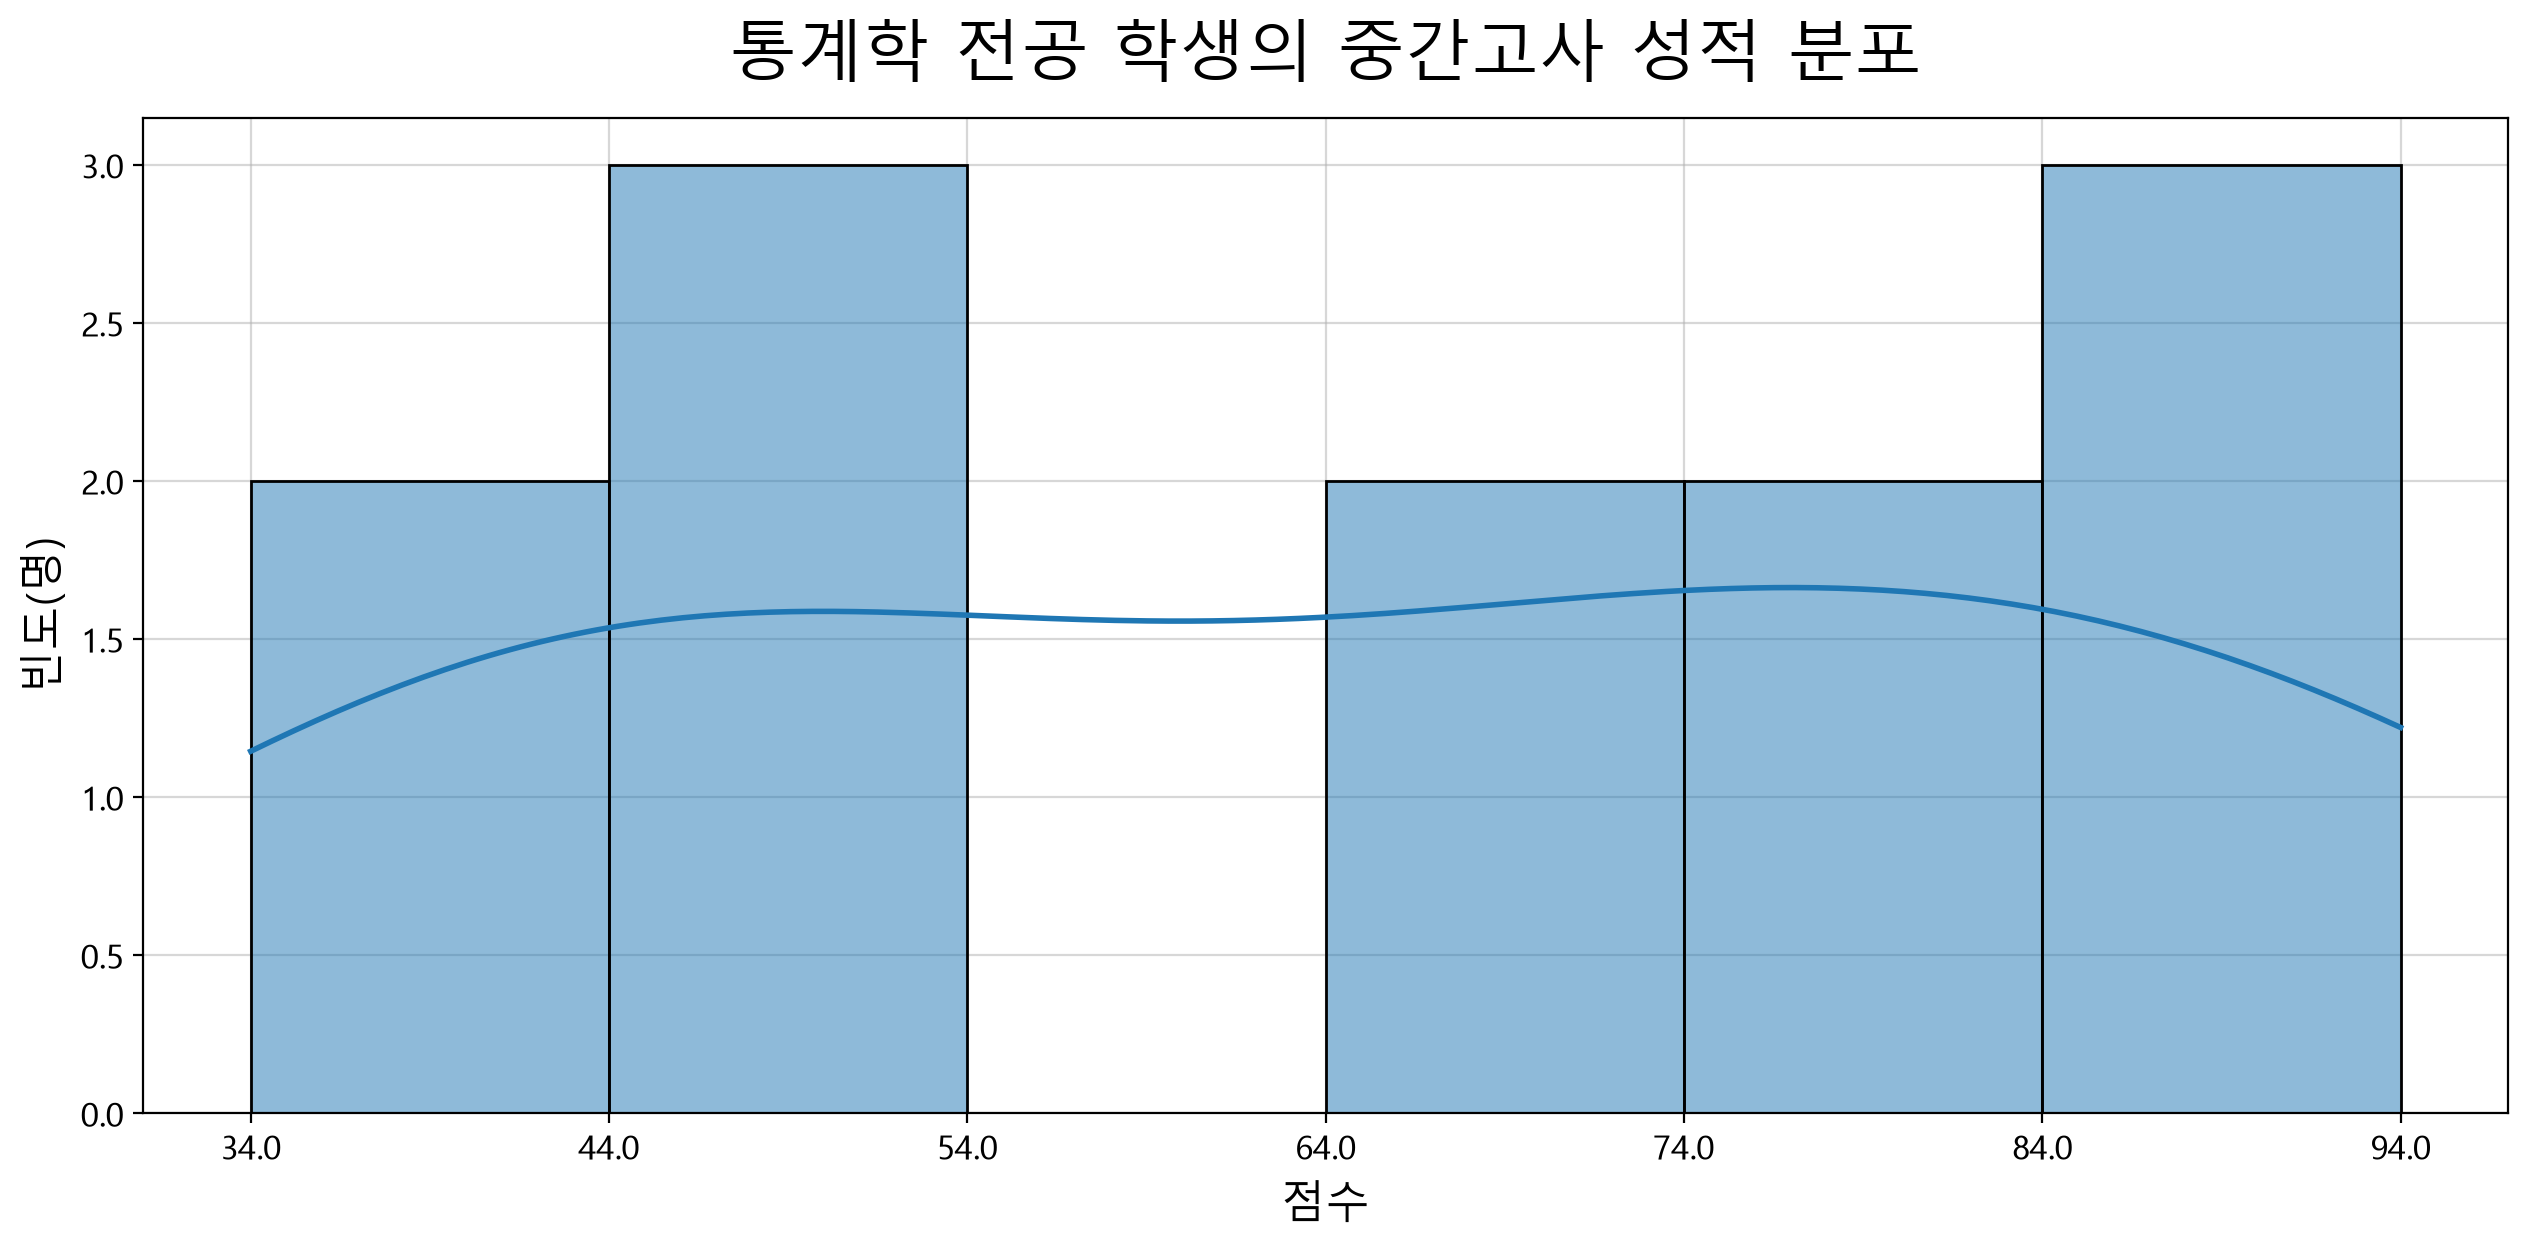

In [18]:
my_plot.histplot(data=df1, 
                 x='중간고사', bins=6, kde=True,
                 title='통계학 전공 학생의 중간고사 성적 분포', 
                 xlabel='점수', ylabel='빈도(명)')

In [19]:
hist, bins = np.histogram(df1['전공'], bins=6)
bins = np.round(bins, 1)


TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

In [ ]:
my_plot.histplot(data=origin, x='전공', hue='전공', 
                 bins=bins, 
                 )

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

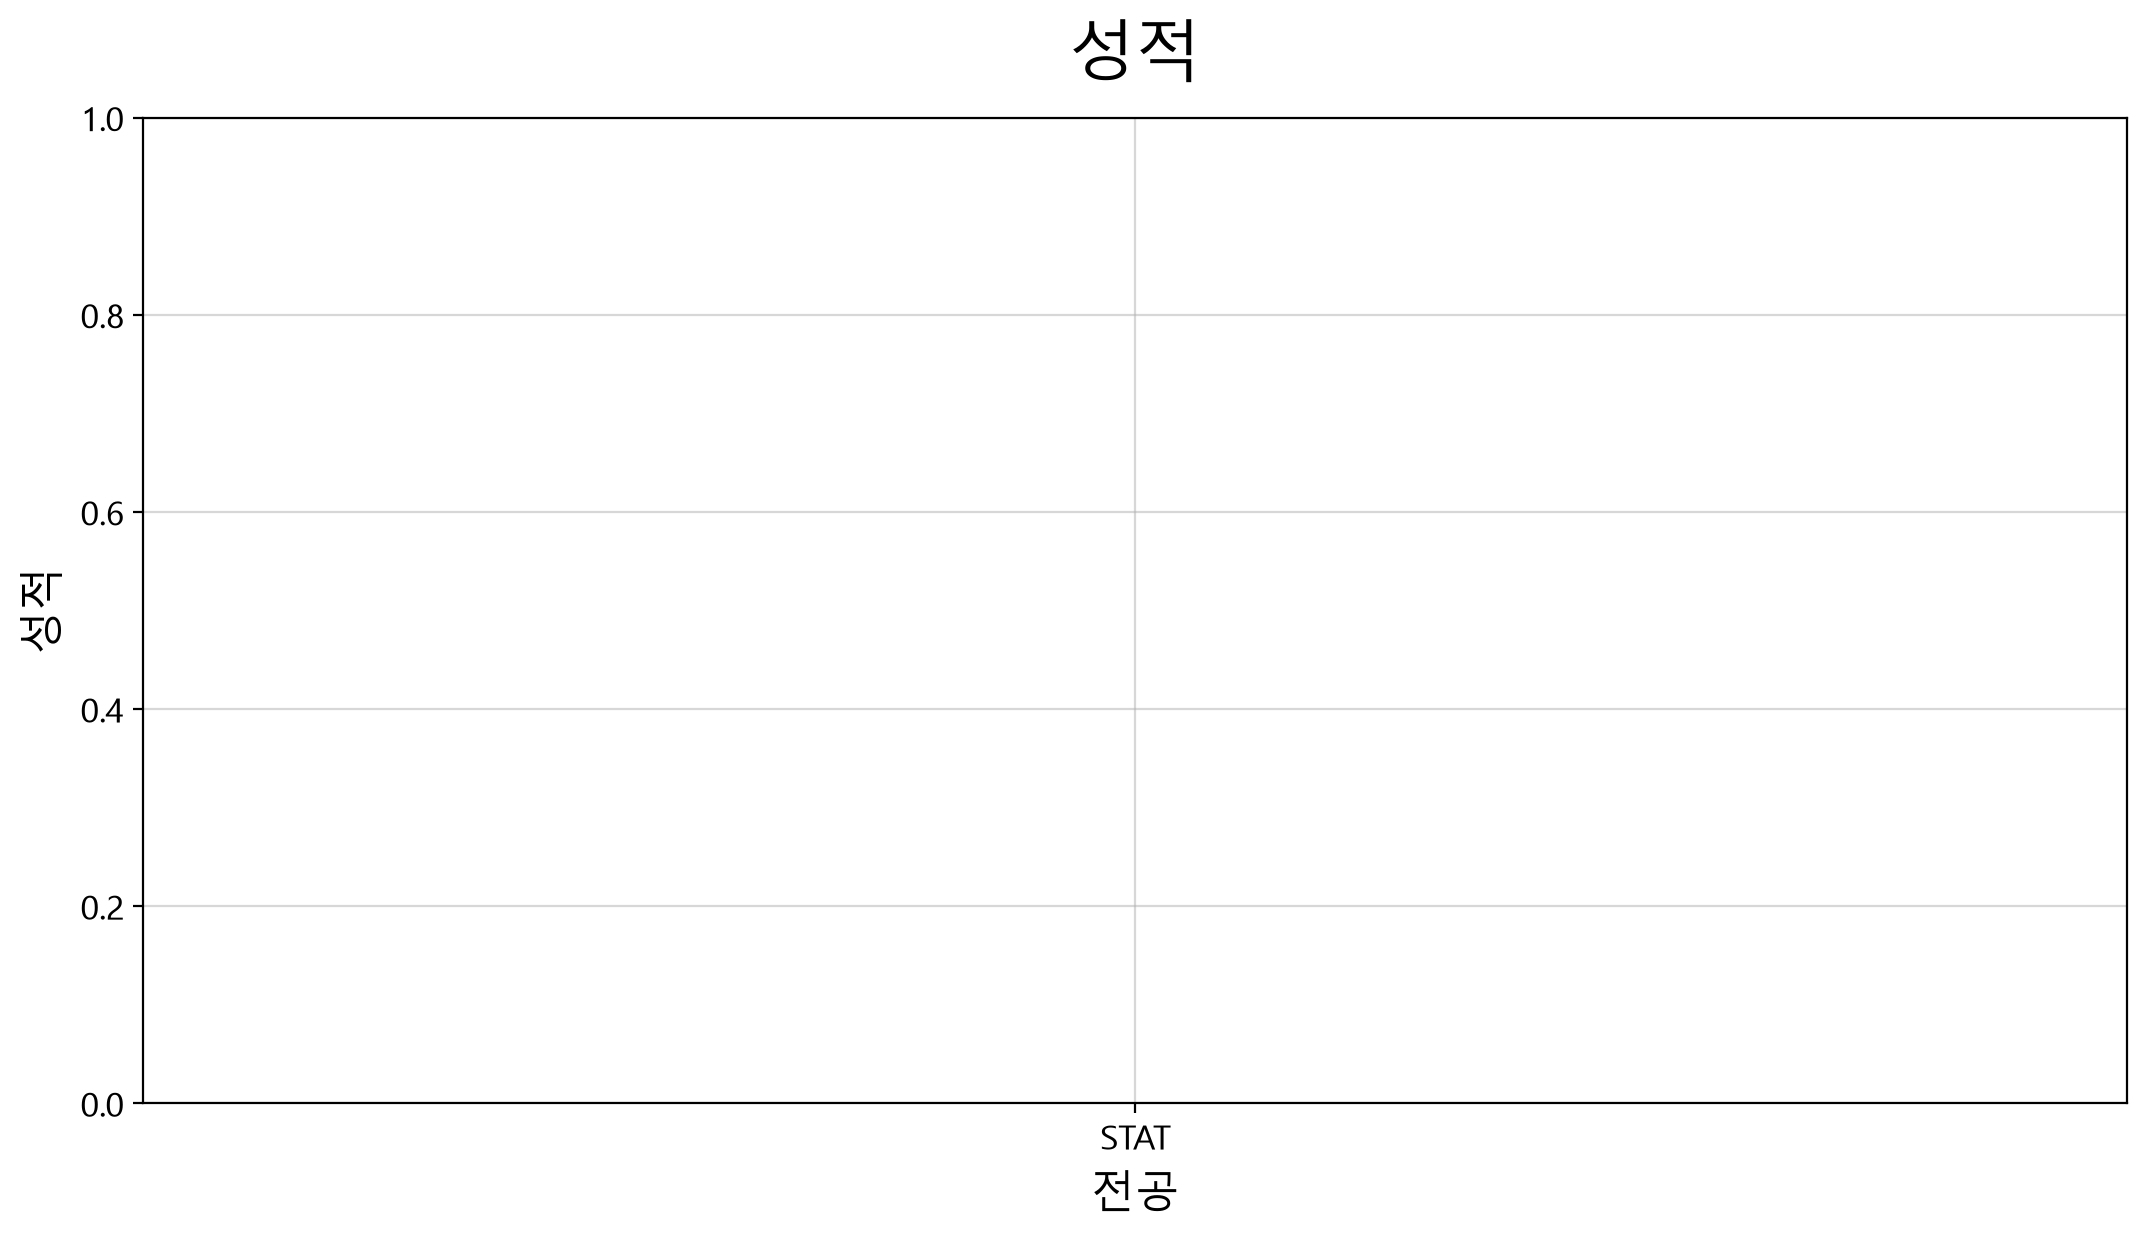

In [ ]:
fig, ax = my_plot.init(title='성적', 
                       xlabel='전공', ylabel='성적')

sb.histplot(data=origin, x='전공', hue='전공', bins=bins)

my_plot.show()